# 02 — Statistical Inference

This notebook applies the inference layer built in `src/football_intelligence/statistics/`
to the real StatsBomb development dataset. **No statistical method is implemented
here.** Every diagnostic, test, bootstrap and permutation is a call into the
production modules, so what this notebook shows is what the library actually does.

Each analysis is written as a small piece of research rather than a function
demonstration, and follows the same skeleton:

> **Question** · **Observational unit** · **H0 and H1** · **Why this test** ·
> **Assumptions** → result → **Magnitude** · **Interpretation** · **Limitations** ·
> **What would make this invalid**

### Rules this notebook follows

- A p-value is never reported alone, and `p < 0.05` is never treated as a
  conclusion by itself. Statistical significance and practical significance are
  separated everywhere.
- Failure to reject H0 is never described as evidence that H0 is true.
- Mann-Whitney is a test of stochastic ordering, **not** of medians.
- Kolmogorov-Smirnov compares whole distributions, **not** means.
- No paired design is invented. Where a natural pairing does not exist, the
  demonstration is explicitly synthetic.

### Structural facts carried forward from `01_data_exploration.ipynb`

These four findings constrain almost every analysis below, so they are stated
once here rather than repeated:

1. **2,918 non-shootout shots.** Period-5 penalty shootouts are a different
   data-generating process (65% conversion) and are excluded from the canonical
   dataset. They stay excluded here.
2. **Shots are clustered within players and matches.** 651 players supply 2,918
   shots, a median of 3 each.
3. **Repeated observations are not iid**, so row-level inference understates
   uncertainty. How badly is an empirical question, answered in §11 and §13.
4. **Coordinate precision differs by competition** (World Cup integer, Euro
   sub-yard), which is confounded with competition and matters for anything
   built on `shot_distance`.

## 0. Setup

Only plotting and data shaping happen in this notebook. Everything statistical
comes from the package.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from football_intelligence.features import shots as shot_features
from football_intelligence.statistics import bootstrap as bs
from football_intelligence.statistics import diagnostics as diag
from football_intelligence.statistics import effect_sizes as eff
from football_intelligence.statistics import multiple_testing as mt
from football_intelligence.statistics import permutation as perm
from football_intelligence.statistics import tests as ht


def find_repository_root(start: Path) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"No pyproject.toml above {start}")


REPO_ROOT = find_repository_root(Path.cwd())
SEED = 20260820

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

shots = shot_features.read_shot_dataset(REPO_ROOT / shot_features.DEFAULT_DATASET_PATH)
open_play = shots[shots["shot_type"] == "Open Play"]

print(f"shots (shootouts already excluded): {len(shots):,}")
print(f"open-play shots:                    {len(open_play):,}")
print(f"matches: {shots['match_id'].nunique()}   players: {shots['player_id'].nunique()}")
print(f"goal rate: {shots['goal'].mean():.4f}")

shots (shootouts already excluded): 2,918
open-play shots:                    2,749
matches: 115   players: 651
goal rate: 0.0987


---

## 1. Diagnostics: what do the variables look like?

**Question.** Before any test: how are shot distance and shot angle distributed,
how much is missing, and how heavy are the tails?

**Observational unit.** One shot.

**Why diagnostics first.** Not to pick a test — that decision belongs to the
design, not to the data — but to know what a mean would be summarising, and
whether outliers are errors or real football.

**What these are not.** The normality statistics below are descriptions. They are
never used to switch between a t-test and a rank test; §3 explains why that
pattern is invalid.

In [2]:
distance_summary = diag.describe_sample(shots["shot_distance"], name="shot_distance (yards)")
angle_summary = diag.describe_sample(np.degrees(shots["shot_angle"]), name="shot_angle (degrees)")
print(distance_summary)
print()
print(angle_summary)

shot_distance (yards)
  n (total / observed / missing)  2,918 / 2,918 / 0 (0.00%)
  mean +- sd                      18.7726 +- 8.4535
  standard error of the mean      0.1565
  median [Q1, Q3], IQR            18.3398 [11.9004, 25.0799], 13.1795
  min / max                       0.7616 / 61.5224
  variance                        71.4623
  MAD                             6.6364
  skewness                        +0.4107
  excess kurtosis                 -0.0837
  Tukey fences                    [-7.869, 44.849] -> 8 outside (0.27%)
  modified z > 3.5              -> 4 outside
  quantiles                       p1=4.243  p5=6.708  p25=11.900  p50=18.340  p75=25.080  p95=32.855  p99=38.901

shot_angle (degrees)
  n (total / observed / missing)  2,918 / 2,918 / 0 (0.00%)
  mean +- sd                      26.0156 +- 17.0515
  standard error of the mean      0.3157
  median [Q1, Q3], IQR            19.9499 [15.0986, 32.2756], 17.1770
  min / max                       2.4153 / 160.0408
  varianc

In [3]:
print(diag.assess_normality(shots["shot_distance"], name="shot_distance (yards)"))
print()
print(diag.assess_normality(np.degrees(shots["shot_angle"]), name="shot_angle (degrees)"))

shot_distance (yards) (n = 2,918)
  skewness                 +0.4107   (0 if symmetric)
  excess kurtosis          -0.0837   (0 if normal)
  Shapiro-Wilk             statistic=0.97576  p=6.985e-22
  D'Agostino-Pearson       statistic=77.12387  p=1.79e-17
  note: At n = 2,918 a normality test detects departures far too small to affect inference; treat a small p-value as a statement about power, not about whether a mean-based method is usable.
  note: These describe the observations. They do not describe the sampling distribution of a statistic, nor model residuals, and they do not determine which hypothesis test is appropriate.

shot_angle (degrees) (n = 2,918)
  skewness                 +2.3832   (0 if symmetric)
  excess kurtosis          +9.0033   (0 if normal)
  Shapiro-Wilk             statistic=0.78049  p=1.253e-52
  D'Agostino-Pearson       statistic=1537.94729  p=0
  note: At n = 2,918 a normality test detects departures far too small to affect inference; treat a small p-value a

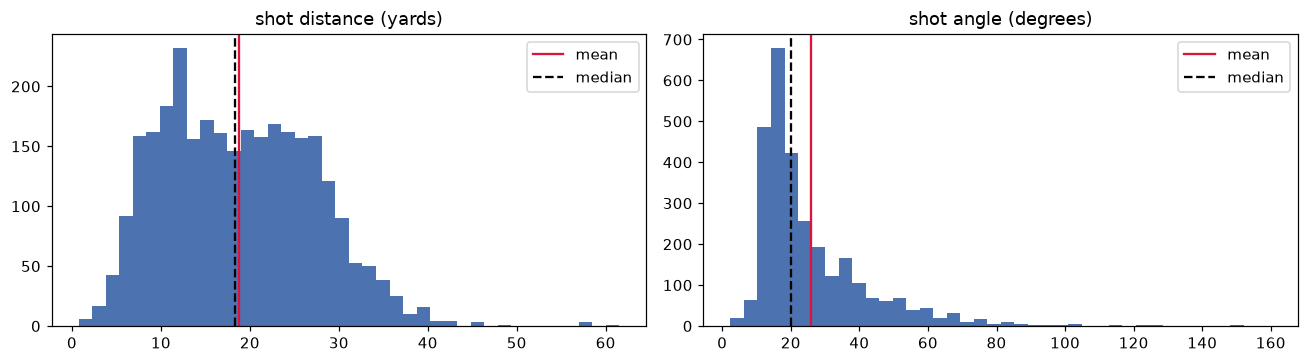

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(shots["shot_distance"], bins=40, color="#4C72B0")
axes[0].axvline(distance_summary.mean, color="crimson", label="mean")
axes[0].axvline(distance_summary.median, color="black", linestyle="--", label="median")
axes[0].set_title("shot distance (yards)")
axes[0].legend()

axes[1].hist(np.degrees(shots["shot_angle"]), bins=40, color="#4C72B0")
axes[1].axvline(angle_summary.mean, color="crimson", label="mean")
axes[1].axvline(angle_summary.median, color="black", linestyle="--", label="median")
axes[1].set_title("shot angle (degrees)")
axes[1].legend()
fig.tight_layout()
plt.show()

**Result.** Distance is mild: skewness +0.41, excess kurtosis −0.08, mean ≈ median,
and only 0.27% of shots fall outside Tukey's fences — *fewer* than normal data
would produce. Angle is not: skewness +2.38, excess kurtosis +9.0, 5.6% outside
the fences, and the mean (26.0°) sits well above the median (19.9°).

**Magnitude.** The standard error of the mean is 0.157 yards for distance and
0.32° for angle — both tiny relative to the spread, because n is large.

**Interpretation.** Both variables "fail" every normality test at p < 1e-16, and
that tells us almost nothing: at n = 2,918 these tests detect departures far too
small to matter. The shape measures are the informative part, and they say
distance is nearly symmetric while angle has a hard floor near 0° and a long right
tail of close-range chances.

**Limitations.** These describe the observations, not the sampling distribution of
any statistic, and not model residuals. For a mean, the central limit theorem does
the work: the usual rule of thumb needs n > 25·skew² ≈ 142 for angle, and we have
2,918.

**What would make this misleading.** Treating the outliers as errors. The 164
"outlying" angles are real close-range chances — exactly the shots that decide
matches — and deleting them would bias every downstream analysis.

---

## 2. Two independent groups: do two teams shoot from different distances?

**Question.** Do the two teams with the most open-play shots in this dataset take
them from different average distances?

**Observational unit.** One open-play shot. Groups are chosen from the data (the
two busiest shooting teams), never by name.

**H0.** The population mean shot distance is the same for both teams.
**H1.** The two means differ (two-sided).

**Why a t-test.** The question is explicitly about a *difference in means*, the two
groups are separate units, and with 149–179 shots per group the central limit
theorem covers the sampling distribution of each mean regardless of the shape of
the raw data.

**Student versus Welch.** Student's version additionally assumes equal population
variances. We have no design reason to believe that, so Welch is the default and
Student is shown only for comparison.

**Assumptions.** Independent observations (**this one is false here** — see §13),
and approximately normal sampling distributions for the two means.

In [5]:
busiest = open_play["team"].value_counts().head(2)
team_a, team_b = (str(name) for name in busiest.index)
pair = open_play[open_play["team"].isin([team_a, team_b])]
distance_a = pair.loc[pair["team"] == team_a, "shot_distance"]
distance_b = pair.loc[pair["team"] == team_b, "shot_distance"]

print(f"selected by shot count: {team_a} ({busiest.iloc[0]}) and {team_b} ({busiest.iloc[1]})")
print()
print(diag.describe_by_group(pair, "shot_distance", "team").round(3).to_string(index=False))

selected by shot count: Spain (179) and Belgium (149)

   team   n  missing   mean   std  standard_error  median     q1     q3    iqr  skewness  excess_kurtosis  tukey_outliers
  Spain 179        0 16.363 7.526           0.563  15.746 10.358 21.303 10.945     0.437           -0.346               0
Belgium 149        0 18.294 7.728           0.633  18.601 12.000 22.847 10.847     0.506            0.624               2


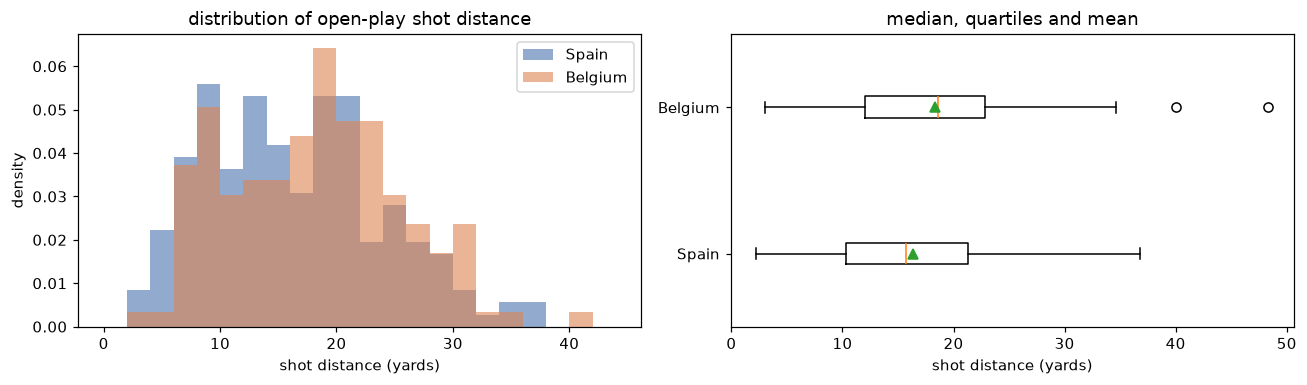

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
bins = np.arange(0, 46, 2)
axes[0].hist(distance_a, bins=bins, alpha=0.6, label=team_a, color="#4C72B0", density=True)
axes[0].hist(distance_b, bins=bins, alpha=0.6, label=team_b, color="#DD8452", density=True)
axes[0].set_xlabel("shot distance (yards)")
axes[0].set_ylabel("density")
axes[0].set_title("distribution of open-play shot distance")
axes[0].legend()

axes[1].boxplot(
    [distance_a, distance_b],
    tick_labels=[team_a, team_b],
    orientation="horizontal",
    showmeans=True,
)
axes[1].set_xlabel("shot distance (yards)")
axes[1].set_title("median, quartiles and mean")
fig.tight_layout()
plt.show()

In [7]:
welch = ht.welch_t_test(distance_a, distance_b, label_a=team_a, label_b=team_b)
student = ht.student_t_test(distance_a, distance_b, label_a=team_a, label_b=team_b)
print(welch)
print()
print(f"Student's t-test for comparison: t = {student.statistic:.4f}, p = {student.p_value:.4f}")
print(f"Welch                          : t = {welch.statistic:.4f}, p = {welch.p_value:.4f}")

Welch's independent t-test
  design            independent samples
  H0                the population means of Spain and Belgium are equal
  H1 (two-sided)    the means of Spain and Belgium differ
  estimand          difference in population means, mean(Spain) - mean(Belgium)
  t                 -2.27948   (df = 312.2)
  p-value           0.0233131
  n                 179 vs 149
  mean difference   -1.93049   95% CI [-3.59684, -0.264138]
  reading           p = 0.02331 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (t = -2.279). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        Observations are assumed independent. Shots are clustered within players, matches and teams, so a test run on raw shot rows will understate the standard error and overstate significance.
  assumption        The sampling distribution of 

**Result.** Welch gives t = −2.28 on 312.2 degrees of freedom, p = 0.023. Student's
version is almost identical here because the group variances are similar, so the
assumption it adds happens to be harmless — which we could only know after looking.

**Magnitude.** This is the part the p-value does not contain: the mean difference is
**−1.93 yards, 95% CI [−3.60, −0.26]**. Spain shoot about two yards closer on
average, and the interval is consistent with anything from a quarter of a yard to
three and a half.

**Interpretation.** Under the assumption that these 328 shots are independent, a
difference this large would be uncommon if the two teams shot from the same average
distance. Two yards is a real football difference — roughly the gap between the
penalty spot and the edge of the six-yard box — but the interval is wide enough
that the practical size is poorly determined.

**Limitations.** The interval and the p-value both assume 328 independent
observations. They are not: these shots come from 51 players across 22 matches.
§13 redoes this comparison with an assumption that survives contact with the data,
and the conclusion changes.

**What would make this invalid.** Choosing the two teams *because* their means
looked different. They were selected on shot count, which is unrelated to the
outcome under H0 — but had they been picked by inspecting distances first, the
p-value would be meaningless.

---

## 3. The same two teams, a different question: Mann-Whitney U

**Question.** Setting means aside: does one of these teams *tend* to shoot from
further out than the other?

**Observational unit.** One open-play shot.

**H0.** The two teams are stochastically equal — a randomly chosen shot from one is
as likely to be longer than a randomly chosen shot from the other as the reverse.
**H1.** They are not stochastically equal.

**Why this test.** It answers a different question from §2, not a more robust
version of it. It is the right choice when the interest is in which group tends to
produce larger values, or when heavy tails make a mean an unrepresentative summary.

**This is not a test of medians.** Under H0 the estimand is the probability of
superiority, P(A > B) + ½P(A = B), which equals 0.5. Two distributions with
identical medians can be rejected by this test, and two with different medians can
fail to be. Reading it as a median comparison requires the extra assumption that
the two distributions have the same shape and spread.

**Why we did not choose it from a normality test.** Selecting between §2 and §3 by
looking at a normality p-value would be invalid three times over: the null of that
test is false by construction at this sample size, conditioning the choice on the
data inflates the error rate of whatever runs second, and the two tests answer
different questions, so the choice belongs to the research question.

In [8]:
mwu = ht.mann_whitney_u_test(distance_a, distance_b, label_a=team_a, label_b=team_b)
print(mwu)

Mann-Whitney U test
  design            independent samples
  H0                Spain and Belgium are stochastically equal: a random observation from one is as likely to exceed a random observation from the other as the reverse
  H1 (two-sided)    Spain and Belgium are not stochastically equal
  estimand          probability of superiority, P(Spain > Belgium) + 0.5 P(equal)
  U                 11393.5
  p-value           0.0231795
  n                 179 vs 149
  P(superiority)    0.427187
  reading           p = 0.02318 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (U = 1.139e+04). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        Observations are assumed independent. Shots are clustered within players, matches and teams, so a test run on raw shot rows will understate the standard error and overstate signifi

**Result.** U = 11,393.5, p = 0.023.

**Magnitude.** The probability of superiority is **0.427**: a randomly chosen Spain
shot is longer than a randomly chosen Belgium shot about 43% of the time, against
50% under H0. That is a modest ordering effect, and it is the estimand — not a
median difference.

**Interpretation.** The two teams' shot distances are ordered slightly differently.
Note that this p-value (0.023) and Welch's (0.023) agree almost exactly, which is
a coincidence of this dataset rather than a general fact: the two tests can and do
disagree when distributions differ in shape.

**Limitations.** 51 tied distance values are present (the World Cup half of the data
is recorded to whole yards), so SciPy uses the tie-corrected normal approximation
rather than an exact distribution. Independence is assumed and is false, exactly as
in §2.

**What would make this invalid.** Reporting it as "the median shot distance
differs". Nothing in this test estimates a median.

---

## 4. Whole distributions: two-sample Kolmogorov-Smirnov

**Question.** Do the two teams' shot-distance *distributions* differ in shape, and
not merely in some summary of them?

**Observational unit.** One open-play shot.

**H0.** Both samples are drawn from the same distribution.
**H1.** They are drawn from different distributions.

**Why this test.** Two samples can share a mean *and* a median and still be shaped
completely differently — one concentrated, the other bimodal. Only a
whole-distribution test notices. The statistic D is the largest vertical gap
between the two empirical CDFs, so it is both the test statistic and a directly
readable measure of separation.

**This is not a test of means.** A significant D can come from a difference in
location, in spread, or in shape, and the test cannot say which.

**Assumptions.** Independent observations, and continuous underlying distributions
— the exact p-value assumes no ties.

In [9]:
ks = ht.kolmogorov_smirnov_test(distance_a, distance_b, label_a=team_a, label_b=team_b)
print(ks)

Two-sample Kolmogorov-Smirnov test
  design            independent samples
  H0                Spain and Belgium are drawn from the same distribution
  H1 (two-sided)    Spain and Belgium are drawn from different distributions
  estimand          supremum distance between the two cumulative distribution functions
  D                 0.142589
  p-value           0.0644643
  n                 179 vs 149
  D (max CDF gap)   0.142589
  reading           p = 0.06446 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (D = 0.1426). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        Observations are assumed independent. Shots are clustered within players, matches and teams, so a test run on raw shot rows will understate the standard error and overstate significance.
  assumption        The underlying distributions are cont

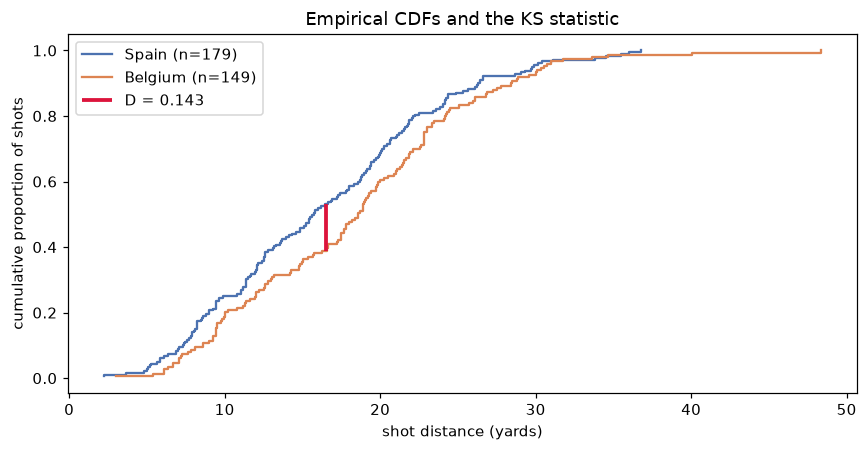

In [10]:
def ecdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Empirical CDF: sorted values and their cumulative proportion."""
    ordered = np.sort(np.asarray(values, dtype=float))
    return ordered, np.arange(1, ordered.size + 1) / ordered.size


x_a, y_a = ecdf(distance_a.to_numpy())
x_b, y_b = ecdf(distance_b.to_numpy())

# Locate the largest vertical gap, which is exactly what D measures.
grid = np.linspace(0, max(x_a.max(), x_b.max()), 600)
cdf_a = np.searchsorted(x_a, grid, side="right") / x_a.size
cdf_b = np.searchsorted(x_b, grid, side="right") / x_b.size
gap_at = int(np.argmax(np.abs(cdf_a - cdf_b)))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.step(x_a, y_a, where="post", label=f"{team_a} (n={x_a.size})", color="#4C72B0")
ax.step(x_b, y_b, where="post", label=f"{team_b} (n={x_b.size})", color="#DD8452")
ax.vlines(
    grid[gap_at],
    min(cdf_a[gap_at], cdf_b[gap_at]),
    max(cdf_a[gap_at], cdf_b[gap_at]),
    color="crimson",
    linewidth=2.5,
    label=f"D = {ks.statistic:.3f}",
)
ax.set_xlabel("shot distance (yards)")
ax.set_ylabel("cumulative proportion of shots")
ax.set_title("Empirical CDFs and the KS statistic")
ax.legend()
fig.tight_layout()
plt.show()

**Result.** D = 0.143, p = 0.064.

**Magnitude.** At the widest point, the two cumulative distributions differ by 14
percentage points, around 14 yards from goal.

**Interpretation — and this is the useful part.** The mean comparison in §2
returned p = 0.023 and this one returns p = 0.064. They are **not in conflict and
neither is "right"**: §2 asks whether the averages differ, §4 asks whether the whole
distributions do, and the evidence for the second is weaker than for the first. A
practice of running several tests and reporting the smallest p-value would be
straightforwardly dishonest; the test has to be chosen from the question.

**Not proof of equality.** p = 0.064 does not mean the distributions are the same.
With 149 and 179 observations this test has limited power, and a real difference in
shape could easily go undetected.

**Limitations.** Ties are present, which makes the p-value conservative. KS has most
of its power near the centre of the distributions and little in the tails, so a
difference confined to long-range shooting would be hard for it to see.

**What would make this invalid.** Describing a rejection as "the teams shoot from
different average distances". That is §2's question, not this one's.

---

## 5. Categorical association: chi-square test of independence

**Question.** Is scoring associated with the body part used for the shot?

**Observational unit.** One open-play shot, each contributing to exactly one cell.

**H0.** Body part and outcome are independent — the conversion rate is the same for
every body part.
**H1.** They are associated.

**Why this test.** Both variables are categorical and every shot falls in exactly
one cell, which is what a contingency test needs. Body-part levels with fewer than
30 shots are dropped so the expected counts stay comfortable.

**Assumptions.** Independent observations, counts (not rates or proportions), and
expected cell counts large enough for the chi-square approximation.

In [11]:
counted = open_play["body_part"].value_counts()
kept = [str(part) for part in counted[counted >= 30].index]
subset = open_play[open_play["body_part"].isin(kept)]
table = pd.crosstab(subset["body_part"], subset["goal"])
display(table)

rates = (
    subset.groupby("body_part")
    .agg(shots=("goal", "size"), goals=("goal", "sum"), conversion=("goal", "mean"))
    .round(4)
)
display(rates)

chi_square = ht.chi_square_independence_test(table)
print(chi_square)

goal,False,True
body_part,,
Head,472,59
Left Foot,750,79
Right Foot,1260,111


,shots,goals,conversion
body_part,,,
Head,531,59,0.1111
Left Foot,829,79,0.0953
Right Foot,1371,111,0.0810


Chi-square test of independence
  design            independent samples
  H0                the row and column variables are independent
  H1 (two-sided)    the row and column variables are associated
  estimand          departure of the joint distribution from the product of its margins
  chi2              4.44231   (df = 2)
  p-value           0.108484
  n                 2,731 in a (3, 2) table
  reading           p = 0.1085 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (chi2 = 4.442). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        Observations are assumed independent. Shots are clustered within players, matches and teams, so a test run on raw shot rows will understate the standard error and overstate significance.
  assumption        Every observation contributes to exactly one cell; the counts are fre

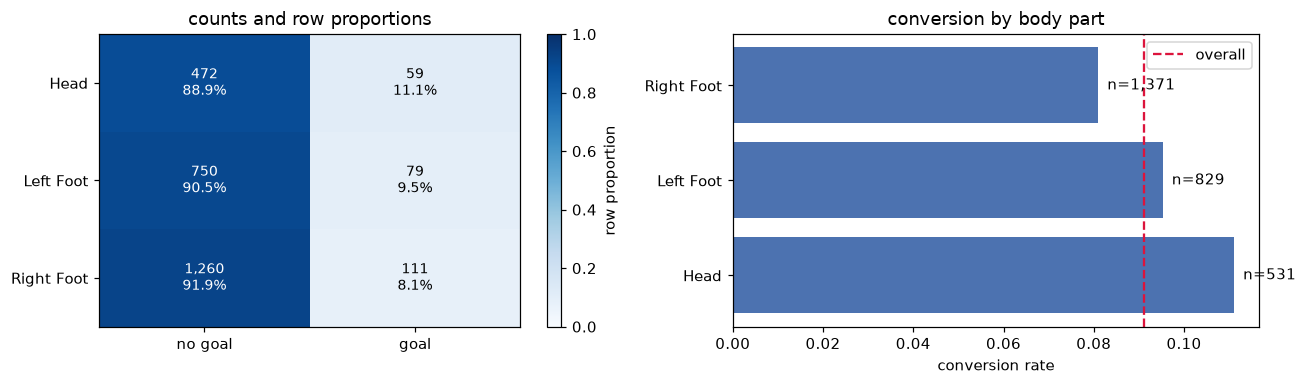

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

proportions = table.div(table.sum(axis=1), axis=0)
image = axes[0].imshow(proportions.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks([0, 1], ["no goal", "goal"])
axes[0].set_yticks(range(len(table.index)), list(table.index))
for row in range(table.shape[0]):
    for column in range(table.shape[1]):
        axes[0].text(
            column,
            row,
            f"{table.to_numpy()[row, column]:,}\n{proportions.to_numpy()[row, column]:.1%}",
            ha="center",
            va="center",
            color="black" if proportions.to_numpy()[row, column] < 0.6 else "white",
            fontsize=9,
        )
axes[0].set_title("counts and row proportions")
fig.colorbar(image, ax=axes[0], label="row proportion")

axes[1].barh(rates.index.astype(str), rates["conversion"], color="#4C72B0")
axes[1].axvline(subset["goal"].mean(), color="crimson", linestyle="--", label="overall")
for position, (_name, row) in enumerate(rates.iterrows()):
    axes[1].text(row["conversion"] + 0.002, position, f"n={int(row['shots']):,}", va="center")
axes[1].set_xlabel("conversion rate")
axes[1].set_title("conversion by body part")
axes[1].legend()
fig.tight_layout()
plt.show()

**Result.** chi2 = 4.44 on 2 degrees of freedom, p = 0.108.

**Magnitude.** Conversion is 11.1% for headers, 9.5% for left foot and 8.1% for
right foot. The spread across body parts is about three percentage points.

**Interpretation.** There is little evidence in this dataset that conversion depends
on body part. That is *not* evidence that it does not — with 2,731 shots and a base
rate near 9%, only fairly large differences would be detectable.

**A trap this table walks straight into.** Headers convert at the *highest* rate
here, which sounds like heading is the best way to score. It is not: from
`01_data_exploration`, headers are taken from a mean of 9.8 yards and foot shots
from about 21. Body part is confounded with distance, and this marginal table
cannot separate the two. A model that conditions on location is the only honest way
to ask the question.

**Limitations.** chi2 is not an effect size — it grows with sample size — which is
why the result object leaves `estimate` empty and points to a measure of association
instead. Independence is assumed and is false: 2,731 shots come from far fewer
players.

**What would make this invalid.** Feeding it proportions or per-90 rates instead of
counts, or letting one shot contribute to two cells.

---

## 6. A 2x2 table with an exact test: Fisher

**Question.** Do headers convert at a different rate from foot shots?

**Observational unit.** One open-play shot.

**H0.** Header/foot and goal/no-goal are independent.
**H1.** They are associated.

**Why this test.** Fisher's test computes the null distribution exactly given both
margins, rather than relying on the chi-square approximation. Here the counts are
large enough that the approximation would be fine, so this is shown as the
small-count tool it is — the case it is actually needed for is a table with a cell
of five.

**Assumptions.** Independent observations, each in exactly one cell, and a p-value
computed conditional on both margins.

In [13]:
binary = subset.assign(header=subset["body_part"] == "Head")
two_by_two = pd.crosstab(binary["header"], binary["goal"])
two_by_two.index = pd.Index(["foot", "header"], name="body part")
display(two_by_two)

fisher = ht.fisher_exact_test(two_by_two)
print(fisher)

goal,False,True
body part,,
foot,2010,190
header,472,59


Fisher's exact test
  design            independent samples
  H0                the row and column variables are independent
  H1 (two-sided)    the row and column variables are associated
  estimand          odds ratio between the two rows
  odds ratio        1.32237
  p-value           0.0780568
  n                 2,731 in a (2, 2) table
  odds ratio        1.32237
  reading           p = 0.07806 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (odds ratio = 1.322). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        Observations are assumed independent. Shots are clustered within players, matches and teams, so a test run on raw shot rows will understate the standard error and overstate significance.
  assumption        Every observation contributes to exactly one cell.
  assumption        The p-value is comput

**Result.** Odds ratio 1.32, p = 0.078.

**Magnitude.** The odds of scoring with a header are about 1.3 times the odds with a
foot. In absolute terms that is 11.1% versus 8.6% conversion — a 2.5 percentage
point difference.

**Interpretation.** Weak evidence of an association, in the direction of headers
converting slightly better, with the same confounding by distance as in §5. An odds
ratio of 1.32 is a modest effect even taken at face value.

**Limitations.** Conditioning on both margins makes the test somewhat conservative
when, as here, the margins were not fixed by design. "Exact" describes the null
distribution, not superior correctness.

**What would make this invalid.** Collapsing a 3-level variable to 2 levels *after*
seeing which split gives the smallest p-value. The header/foot split here is
substantive and was chosen before looking.

---

## 7. A genuinely paired design: teams before and after the group stage

**Question.** Do teams shoot from different distances once they reach the knockout
rounds, where opponents are stronger and matches more cautious?

**Observational unit.** **A team in one tournament** — not a shot. Each unit is
measured twice: its mean shot distance in the group stage and in the knockout
rounds. The pairing comes from the design, and every team is its own control, which
removes the large differences in shooting style between teams.

**H0.** The mean within-pair difference (group stage − knockout) is zero.
**H1.** It is not zero.

**Why a paired test.** Because the two measurements come from the same unit. Using
an independent-samples test here would throw away the matching *and* violate
independence, since the same team appears in both samples.

**Pairings that would be fabrications.** Two are tempting and both are wrong:

- *Headers versus foot shots "paired by player".* There is no one-to-one
  correspondence — players take different numbers of each and many take only one
  kind — so there is nothing to difference. That is the independent multi-group
  design of §10.
- *Two teams' shots aligned by row order.* Equal lengths do not create a pairing.
  Nothing links Spain's 12th shot to Belgium's 12th shot.

**Assumptions.** Pairs independent of one another; within-pair differences
approximately normal or enough pairs for the CLT. The original measurements need
not be normal, and their correlation is what the design exploits.

In [14]:
phased = shots.assign(phase=np.where(shots["stage"] == "Group Stage", "group", "knockout"))
per_phase = phased.groupby(["competition_id", "team", "phase"], as_index=False).agg(
    mean_distance=("shot_distance", "mean"), shots=("shot_distance", "size")
)
paired = per_phase[per_phase["phase"] == "group"].merge(
    per_phase[per_phase["phase"] == "knockout"],
    on=["competition_id", "team"],
    suffixes=("_group", "_knockout"),
)
paired = paired[(paired["shots_group"] >= 5) & (paired["shots_knockout"] >= 5)]
paired["difference"] = paired["mean_distance_group"] - paired["mean_distance_knockout"]

print(f"{len(paired)} team-tournaments with at least 5 shots in each phase")
display(
    paired[
        [
            "team",
            "shots_group",
            "mean_distance_group",
            "shots_knockout",
            "mean_distance_knockout",
            "difference",
        ]
    ]
    .head(8)
    .round(2)
)

32 team-tournaments with at least 5 shots in each phase


,team,shots_group,mean_distance_group,shots_knockout,mean_distance_knockout,difference
0,Argentina,46,19.58,12,18.33,1.24
1,Belgium,52,18.34,56,17.95,0.39
2,Brazil,59,18.09,44,17.88,0.21
3,Colombia,27,20.00,14,21.75,-1.74
4,Croatia,38,21.60,76,19.57,2.03
5,Denmark,26,21.42,14,21.92,-0.50
6,England,41,16.27,55,18.12,-1.85
7,France,35,20.38,47,19.85,0.53


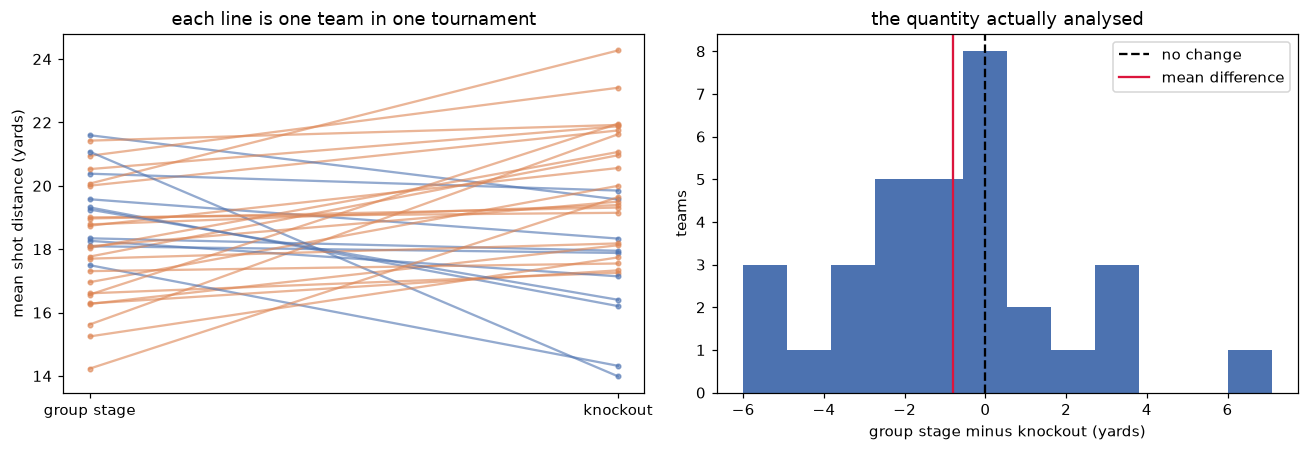

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for _, row in paired.iterrows():
    axes[0].plot(
        [0, 1],
        [row["mean_distance_group"], row["mean_distance_knockout"]],
        color="#4C72B0" if row["difference"] > 0 else "#DD8452",
        alpha=0.6,
        marker="o",
        markersize=3,
    )
axes[0].set_xticks([0, 1], ["group stage", "knockout"])
axes[0].set_ylabel("mean shot distance (yards)")
axes[0].set_title("each line is one team in one tournament")

axes[1].hist(paired["difference"], bins=12, color="#4C72B0")
axes[1].axvline(0, color="black", linestyle="--", label="no change")
axes[1].axvline(paired["difference"].mean(), color="crimson", label="mean difference")
axes[1].set_xlabel("group stage minus knockout (yards)")
axes[1].set_ylabel("teams")
axes[1].set_title("the quantity actually analysed")
axes[1].legend()
fig.tight_layout()
plt.show()

In [16]:
paired_t = ht.paired_t_test(
    paired["mean_distance_group"],
    paired["mean_distance_knockout"],
    label_a="group stage",
    label_b="knockout",
)
print(paired_t)

Paired t-test
  design            paired samples
  H0                the mean of the within-pair differences (group stage - knockout) is zero
  H1 (two-sided)    the mean within-pair difference (group stage - knockout) is not zero
  estimand          mean within-pair difference, group stage - knockout
  t                 -1.63395   (df = 31)
  p-value           0.112386
  n                 32 matched pairs
  mean difference   -0.792233   95% CI [-1.78111, 0.19664]
  reading           p = 0.1124 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (t = -1.634). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        The pairing is real: each pair is one unit measured twice, matched by design rather than by position in an array.
  assumption        The pairs are independent of one another. The two measurements within a pair

**Result.** t = −1.63 on 31 degrees of freedom, p = 0.112.

**Magnitude.** Mean within-pair difference **−0.79 yards, 95% CI [−1.78, +0.20]**.
Teams shoot from slightly closer in the knockout rounds on average, but the interval
comfortably includes zero and excludes anything larger than about two yards.

**Interpretation.** No convincing evidence that shooting distance changes between
phases, and the interval rules out a large effect in either direction. That is a
more useful statement than the p-value alone: the data are consistent with no change
and inconsistent with a change of more than ~1.8 yards.

**Limitations.**

- Only teams that *qualified* can appear, so this describes qualifiers, not all
  teams.
- Knockout matches are contested between two teams that are both in the sample, so
  the 32 pairs are not fully independent of each other.
- Each unit's mean averages between 5 and 76 shots, so the pair differences have
  very unequal precision while the test weights them equally.

**What would make this invalid.** Adding teams with one or two shots in a phase.
Their "mean" would be almost pure noise, and the paired test has no way to know
that one pair is far less precisely measured than another.

---

## 8. The same pairs, rank-based: Wilcoxon signed-rank

**Question.** Same as §7, without assuming the differences are well summarised by a
mean.

**Observational unit.** A team in one tournament — 32 matched pairs.

**H0.** The within-pair differences are distributed symmetrically about zero.
**H1.** They are not.

**Why this test.** It is the rank-based counterpart of §7, useful when the
differences are heavy tailed or one pair could dominate a mean.

**This is not simply a test of the median difference.** Reading it that way requires
the additional assumption that the difference distribution is symmetric — which the
test neither makes nor checks.

**Assumptions.** Real pairing, independent pairs, and differences whose magnitudes
are comparable across pairs, since the procedure ranks them against each other.

In [17]:
wilcoxon = ht.wilcoxon_signed_rank_test(
    paired["mean_distance_group"],
    paired["mean_distance_knockout"],
    label_a="group stage",
    label_b="knockout",
)
print(wilcoxon)

Wilcoxon signed-rank test
  design            paired samples
  H0                the within-pair differences (group stage - knockout) are distributed symmetrically about zero
  H1 (two-sided)    the within-pair differences (group stage - knockout) are not distributed symmetrically about zero
  estimand          location of the within-pair difference distribution (group stage - knockout) relative to zero, in signed-rank terms
  W                 164
  p-value           0.0622172
  n                 32 matched pairs
  median difference -0.629296
  reading           p = 0.06222 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (W = 164). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        The pairing is real and the pairs are independent of one another.
  assumption        The differences are at least ordinal and thei

**Result.** W = 164, p = 0.062.

**Magnitude.** The median within-pair difference is −0.63 yards, close to the mean
of −0.79 from §7, which tells us no single pair is driving the result.

**Interpretation.** Slightly stronger evidence than the paired t-test, but the same
conclusion: nothing here establishes a change in shooting distance between phases.
The two p-values (0.112 and 0.062) straddle 0.05, which is a good reminder that a
threshold is a reporting convention and not a fact about football.

**Limitations.** The estimator that actually corresponds to this test is the
Hodges-Lehmann pseudomedian, not the median difference reported for description. All
the design limits from §7 carry over unchanged.

**What would make this invalid.** The same fabricated pairings listed in §7.

---

## 9. Why pairing is worth having — a clearly synthetic illustration

Everything in this section is **synthetic**. It exists to show what the paired
design in §7–§8 buys, which real data cannot demonstrate cleanly because we cannot
observe the same teams both paired and unpaired.

The setup: 40 units that differ a lot from each other, each improving by a
consistent small amount. This is exactly the structure a paired design is for.

SYNTHETIC DATA, 40 units, true shift = +2.0
  paired t-test        p = 8.45e-12, estimate -2.19
  independent (Welch)  p = 0.549, estimate -2.19


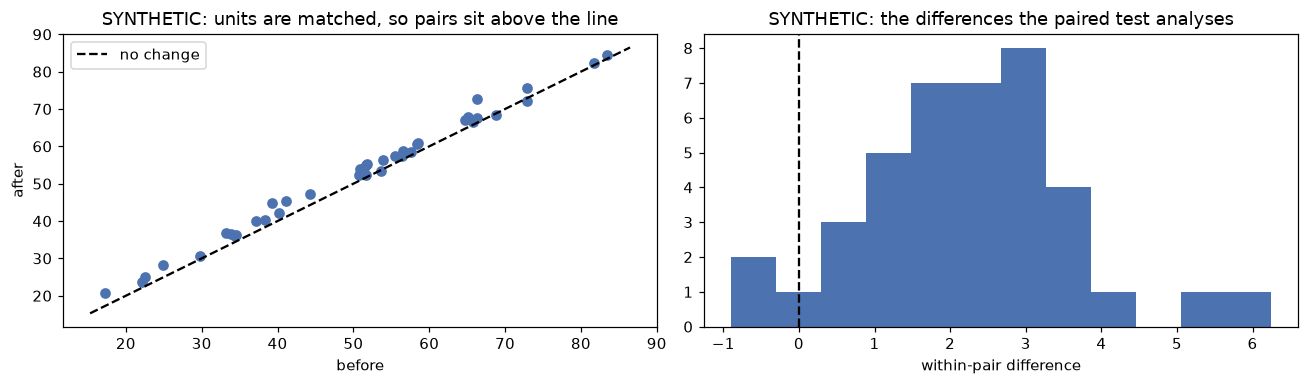

In [18]:
rng = np.random.default_rng(SEED)
unit_level = rng.normal(50.0, 15.0, size=40)  # SYNTHETIC: large between-unit spread
before = unit_level + rng.normal(0.0, 1.0, size=40)
after = unit_level + 2.0 + rng.normal(0.0, 1.0, size=40)  # a consistent +2 shift

paired_synthetic = ht.paired_t_test(before, after, label_a="before", label_b="after")
independent_synthetic = ht.welch_t_test(before, after, label_a="before", label_b="after")

print(f"SYNTHETIC DATA, {len(before)} units, true shift = +2.0")
print(
    f"  paired t-test        p = {paired_synthetic.p_value:.3g}, "
    f"estimate {paired_synthetic.estimate:+.2f}"
)
print(
    f"  independent (Welch)  p = {independent_synthetic.p_value:.3g}, "
    f"estimate {independent_synthetic.estimate:+.2f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].scatter(before, after, color="#4C72B0")
limits = [min(before.min(), after.min()) - 2, max(before.max(), after.max()) + 2]
axes[0].plot(limits, limits, color="black", linestyle="--", label="no change")
axes[0].set_xlabel("before")
axes[0].set_ylabel("after")
axes[0].set_title("SYNTHETIC: units are matched, so pairs sit above the line")
axes[0].legend()

axes[1].hist(after - before, bins=12, color="#4C72B0")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("within-pair difference")
axes[1].set_title("SYNTHETIC: the differences the paired test analyses")
fig.tight_layout()
plt.show()

**Result.** Both tests recover the same effect (estimate −2.19: "after" exceeds
"before" by 2.19, against a true shift of +2.0). The paired test returns
p = 8.5e-12; the independent test returns p = 0.55.

**Interpretation.** Identical numbers, identical estimate, and opposite conclusions.
The independent test drowns a real effect in between-unit variation that the paired
design removes by construction. This is why the design must be established before
the test is chosen, and why fabricating a pairing is not a harmless shortcut: it
would manufacture precision that the data does not contain.

**Why this is synthetic.** Nothing in the StatsBomb dataset provides two
measurements of the same unit under conditions we control, so this contrast cannot
be shown on real football data without inventing the pairing — which §7 explains we
will not do.

---

## 10. Three or more groups: one-way ANOVA

**Question.** Do shots taken with different body parts come from different
distances?

**Observational unit.** One open-play shot.

**H0.** All three group means are equal.
**H1.** At least one differs.

**Why this test.** Three independent groups and one continuous outcome. Running three
pairwise t-tests instead would inflate the error rate; a single omnibus test asks
the question once.

**Which ANOVA.** The classic F test assumes equal variances across groups. Here they
differ by a factor of 6.2 with group sizes from 531 to 1,371 — the configuration in
which the classic test is least trustworthy — so **Welch's ANOVA is the appropriate
choice** and the classic one is shown to make the contrast visible. Kruskal-Wallis
answers the rank-based version of the question.

**Assumptions.** Independent observations within and between groups. **This is
badly violated**, and §10b measures how badly.

  Right Foot   n=1,371  mean= 20.90  sd= 7.92  variance=  62.77
  Left Foot    n=  829  mean= 20.13  sd= 7.58  variance=  57.39
  Head         n=  531  mean=  9.76  sd= 3.17  variance=  10.06


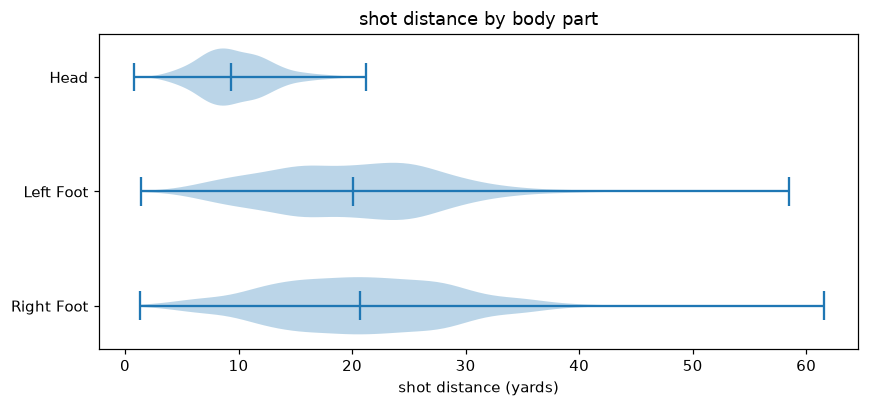

In [19]:
groups = ht.group_samples(subset, "shot_distance", "body_part")
for name, sample in groups.items():
    print(
        f"  {name:<12} n={sample.size:>5,}  mean={sample.mean():6.2f}  "
        f"sd={sample.std(ddof=1):5.2f}  variance={sample.var(ddof=1):7.2f}"
    )

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.violinplot([groups[name] for name in groups], showmedians=True, orientation="horizontal")
ax.set_yticks(range(1, len(groups) + 1), list(groups))
ax.set_xlabel("shot distance (yards)")
ax.set_title("shot distance by body part")
fig.tight_layout()
plt.show()

In [20]:
classic = ht.one_way_anova(groups)
welch_f = ht.welch_anova(groups)
kruskal = ht.kruskal_wallis_test(groups)
print(classic)
print()
print(f"Welch's ANOVA   F = {welch_f.statistic:.2f}, p = {welch_f.p_value:.3g}")
print(f"Kruskal-Wallis  H = {kruskal.statistic:.2f}, p = {kruskal.p_value:.3g}")

One-way ANOVA
  design            independent multi-group
  H0                all group means are equal
  H1 (two-sided)    at least one group mean differs from the others
  estimand          variation between group means relative to variation within groups
  F                 497.491   (df = 2)
  p-value           6.26003e-185
  n                 2,731 in 3 groups
  groups            Right Foot (1,371), Left Foot (829), Head (531)
  reading           p = 6.26e-185 is the probability, if the null hypothesis were true, of data at least as extreme as this sample (F = 497.5). It is not the probability that the null is true, a large value is not evidence for it, and it says nothing about whether the effect is large enough to matter.
  assumption        Observations within each group are independent draws. Shots are not: one player contributes many, so residuals are correlated within player, the within-group mean square is too small, and F is inflated. See the module docstring.
  assumption

**Result.** Classic F = 497.5 (p ≈ 6e-185), Welch F = 1263.2, Kruskal-Wallis
H = 830.4. All three point the same way.

**Magnitude.** This is the substantive finding: headers come from a mean of **9.8
yards**, left foot **20.1**, right foot **20.9**. The header gap is roughly eleven
yards — practically enormous, and far more informative than any of the p-values.

**Interpretation.** Headers are taken from less than half the distance of foot
shots. This is not a subtle statistical finding; it is a fact about how headed
chances arise (crosses and set pieces near goal). Its main use is as a warning
about §5 and §6, where body part looked like it might affect conversion.

**Limitations.** F is not an effect size. The three-group means above are the effect,
and a formal measure such as eta-squared belongs to the effect-size module.

**What would make this invalid.** Reporting the classic F as the answer while the
variance ratio is 6.2 — which is why the result object warns about exactly that.

### 10b. What clustering does to that ANOVA

The F statistic above treats 2,731 shots as 2,731 independent observations. They
come from 643 players. Here is what happens when the unit of analysis changes.

In [21]:
player_means = subset.groupby(["player_id", "body_part"], as_index=False).agg(
    mean_distance=("shot_distance", "mean")
)
aggregated = ht.one_way_anova(ht.group_samples(player_means, "mean_distance", "body_part"))
spanning = player_means.groupby("player_id").size()

print(
    f"one shot per row      F = {classic.statistic:8.2f}  p = {classic.p_value:.3g}  "
    f"n = {classic.n_total:,}"
)
print(
    f"one player-mean/row   F = {aggregated.statistic:8.2f}  p = {aggregated.p_value:.3g}  "
    f"n = {aggregated.n_total:,}"
)
print(
    f"\nplayers appearing in more than one body-part group: "
    f"{int((spanning > 1).sum())} of {len(spanning)}"
)

one shot per row      F =   497.49  p = 6.26e-185  n = 2,731
one player-mean/row   F =   306.46  p = 9.76e-106  n = 1,062

players appearing in more than one body-part group: 322 of 643


**Interpretation.** The F statistic falls by 38% once each player contributes one
value per group instead of one per shot, because the within-group mean square was
measuring variation *within* players as though it were variation *between* them.

**But aggregating is not a fix.** 322 of 643 players appear in more than one
body-part group, so the aggregated comparison is a *repeated-measures* design, not a
one-way one. **Neither number above is a valid test.** The valid analysis is a mixed
model with a player random intercept, or inference that resamples whole players —
which is exactly what §11 and §13 do.

The substantive conclusion (headers come from much closer) is so large that no
correction will overturn it. That is precisely why the magnitude matters more than
the p-value: an eleven-yard gap survives any reasonable treatment of dependence,
whereas the two-yard team difference in §2 does not.

---

## 11. Bootstrap: how precisely do we know these quantities?

**Question.** What is the uncertainty around the overall mean shot distance and the
overall conversion rate?

**Observational unit.** This is the entire point of the section, and we vary it: one
shot, one match, or one player.

**No null hypothesis.** A bootstrap does not test anything. It resamples the data as
it stands to build a sampling distribution around the observed value, producing a
standard error and an interval.

**Why bootstrap at all here.** For a mean there is a textbook formula, and agreement
with it is a useful check that the machinery works. The reason to use resampling is
that the *cluster* version has no convenient closed form, and neither does a
quantity like goals minus expected goals.

**Assumptions.** Whatever unit is declared exchangeable really is. Resampling shots
assumes 2,918 independent observations exist.

In [22]:
distance = shots["shot_distance"].to_numpy()
goal = shots["goal"].to_numpy()
matches = shots["match_id"].to_numpy()
players = shots["player_id"].to_numpy()


def mean_of(sample: np.ndarray) -> float:
    return float(np.mean(sample))


RESAMPLES = 5000
by_shot, by_match = bs.compare_resampling_units(
    distance,
    mean_of,
    clusters=matches,
    n_resamples=RESAMPLES,
    random_state=SEED,
    statistic_name="mean shot distance",
    cluster_name="match",
)
by_player = bs.bootstrap(
    distance,
    mean_of,
    clusters=players,
    n_resamples=RESAMPLES,
    random_state=SEED,
    statistic_name="mean shot distance (players)",
    cluster_name="player",
)
print(by_shot)
print()
print(by_match)
print()
print(by_player)

mean shot distance (resampling shots)
  observed          18.7726
  standard error    0.155328
  95% percentile CI  [18.4627, 19.0793]   width 0.616638
  resampled         2,918 individual observations (2,918 rows)
  resamples         5,000
  bias              -0.00386392
  note              Percentile intervals assume the bootstrap distribution is a good stand-in for the sampling distribution and is not strongly biased or skewed.
  note              Rows were resampled individually, which assumes they are independent.

mean shot distance (resampling match clusters)
  observed          18.7726
  standard error    0.16623
  95% percentile CI  [18.4558, 19.1021]   width 0.646317
  resampled         115 match clusters (2,918 rows)
  resamples         5,000
  bias              +0.00308699
  note              Percentile intervals assume the bootstrap distribution is a good stand-in for the sampling distribution and is not strongly biased or skewed.
  note              Whole match clusters w

In [23]:
analytical = float(np.std(distance, ddof=1) / np.sqrt(distance.size))
comparison = pd.DataFrame(
    {
        "standard error": [
            analytical,
            by_shot.standard_error,
            by_match.standard_error,
            by_player.standard_error,
        ],
        "CI low": [np.nan, *[r.confidence_interval[0] for r in (by_shot, by_match, by_player)]],
        "CI high": [np.nan, *[r.confidence_interval[1] for r in (by_shot, by_match, by_player)]],
        "vs shot-level": [
            analytical / by_shot.standard_error,
            1.0,
            by_match.standard_error / by_shot.standard_error,
            by_player.standard_error / by_shot.standard_error,
        ],
    },
    index=[
        "analytical (independence)",
        "bootstrap: shots",
        "bootstrap: matches",
        "bootstrap: players",
    ],
)
display(comparison.round(4))

,standard error,CI low,CI high,vs shot-level
analytical (independence),0.1565,NaN,NaN,1.0075
bootstrap: shots,0.1553,18.4627,19.0793,1.0000
bootstrap: matches,0.1662,18.4558,19.1021,1.0702
bootstrap: players,0.2535,18.2880,19.2731,1.6322


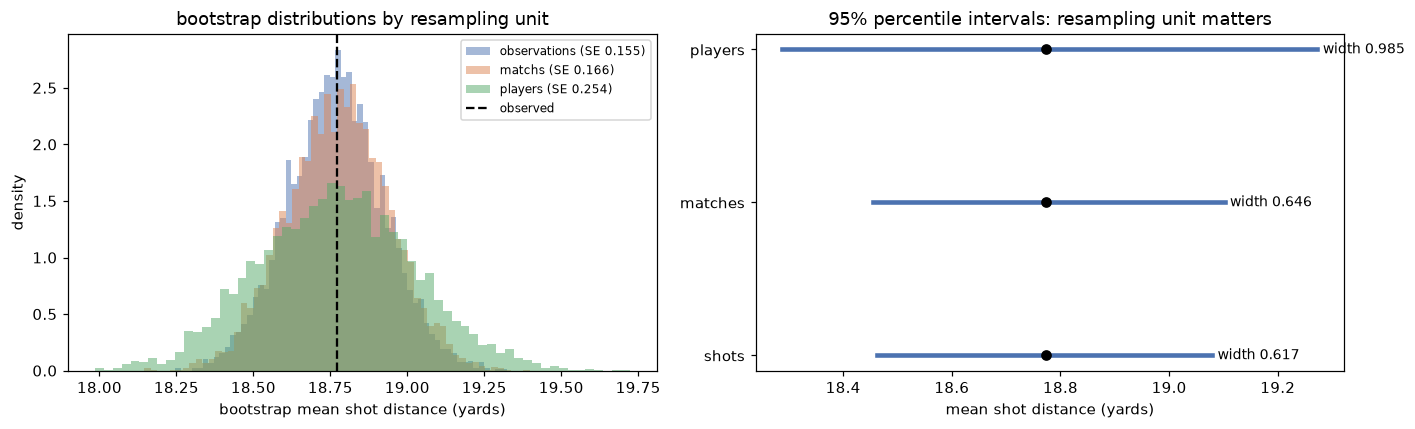

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))

for result, colour in zip(
    (by_shot, by_match, by_player), ("#4C72B0", "#DD8452", "#55A868"), strict=True
):
    axes[0].hist(
        result.replicates,
        bins=60,
        alpha=0.5,
        density=True,
        color=colour,
        label=f"{result.resampling_unit}s (SE {result.standard_error:.3f})",
    )
axes[0].axvline(by_shot.observed, color="black", linestyle="--", label="observed")
axes[0].set_xlabel("bootstrap mean shot distance (yards)")
axes[0].set_ylabel("density")
axes[0].set_title("bootstrap distributions by resampling unit")
axes[0].legend(fontsize=8)

labels = ["shots", "matches", "players"]
for position, result in enumerate((by_shot, by_match, by_player)):
    low, high = result.confidence_interval
    axes[1].plot([low, high], [position, position], linewidth=3, color="#4C72B0")
    axes[1].plot(result.observed, position, "o", color="black")
    axes[1].text(high + 0.01, position, f"width {high - low:.3f}", va="center", fontsize=9)
axes[1].set_yticks(range(3), labels)
axes[1].set_xlabel("mean shot distance (yards)")
axes[1].set_title("95% percentile intervals: resampling unit matters")
fig.tight_layout()
plt.show()

**Result.** Mean shot distance 18.77 yards.

| resampling unit | standard error | vs shot-level |
| --- | ---: | ---: |
| analytical, assuming independence | 0.1565 | 1.01x |
| bootstrap: shots | 0.1553 | 1.00x |
| bootstrap: matches | 0.1662 | **1.07x** |
| bootstrap: players | 0.2535 | **1.63x** |

**Interpretation — and this contradicts the obvious expectation.** The shot-level
bootstrap reproduces the textbook formula almost exactly, confirming the
implementation. Resampling **matches** barely widens the interval, because shot
distance varies far more *within* a match — across both teams and every situation —
than between matches. Resampling **players** widens it by 63%, because a player's
shots genuinely resemble each other: a centre-back heads from eight yards and a
midfielder shoots from twenty-five, week after week.

**Why they differ.** The cluster bootstrap keeps every row of a drawn cluster
together, so any dependence inside that cluster is preserved in each resample.
If rows within a cluster are similar, resampling clusters produces more variable
statistics than resampling rows, and the interval widens by roughly
`sqrt(1 + (m − 1)ρ)`. The match bootstrap is nearly identical to the shot bootstrap
because ρ is close to zero for distance *within a match*; the player bootstrap is
not, because ρ is substantial *within a player*.

**The practical lesson.** "Cluster by match" is the reflex answer and it is the wrong
one for this statistic. The right cluster is an empirical question about where the
dependence actually lives, and it depends on the statistic as well as the data.

**Limitations.** Percentile intervals assume the bootstrap distribution is a fair
stand-in for the sampling distribution and is not strongly biased; the reported
biases here are all below 0.005 yards. With 115 matches the match-level bootstrap is
near the lower end of what is comfortable.

In [25]:
rate_by_shot, rate_by_match = bs.compare_resampling_units(
    goal,
    mean_of,
    clusters=matches,
    n_resamples=RESAMPLES,
    random_state=SEED,
    statistic_name="conversion rate",
    cluster_name="match",
)
rate_by_player = bs.bootstrap(
    goal,
    mean_of,
    clusters=players,
    n_resamples=RESAMPLES,
    random_state=SEED,
    statistic_name="conversion rate (players)",
    cluster_name="player",
)
rate = float(np.mean(goal))
binomial = float(np.sqrt(rate * (1 - rate) / goal.size))

print(f"conversion rate {rate:.4f}")
print(f"  analytical binomial   SE = {binomial:.5f}")
print(
    f"  bootstrap: shots      SE = {rate_by_shot.standard_error:.5f}  "
    f"CI [{rate_by_shot.confidence_interval[0]:.4f}, {rate_by_shot.confidence_interval[1]:.4f}]"
)
print(
    f"  bootstrap: matches    SE = {rate_by_match.standard_error:.5f}  "
    f"({rate_by_match.standard_error / rate_by_shot.standard_error:.2f}x)"
)
print(
    f"  bootstrap: players    SE = {rate_by_player.standard_error:.5f}  "
    f"({rate_by_player.standard_error / rate_by_shot.standard_error:.2f}x)"
)

conversion rate 0.0987
  analytical binomial   SE = 0.00552
  bootstrap: shots      SE = 0.00562  CI [0.0881, 0.1097]
  bootstrap: matches    SE = 0.00576  (1.02x)
  bootstrap: players    SE = 0.00654  (1.16x)


**Conversion rate: 9.87%, 95% CI [8.8%, 11.0%]** at shot level.

Clustering matters far less here — matches 1.02x, players 1.16x — because whether a
shot goes in is close to a coin flip *given* the chance, so little is shared within a
player beyond a modest trace of finishing skill and chance quality. The binomial
formula is nearly adequate for this statistic, while being 63% too narrow for mean
shot distance on the very same rows. Neither fact could have been assumed in advance.

---

## 12. Permutation testing on a controlled synthetic case

**Why synthetic first.** §13 applies a permutation test to real football data, but
the *validity* argument is easiest to see on data whose structure we control. Here
there is **no group effect at all** — only cluster effects — so a correct test should
rarely reject.

In [26]:
rng = np.random.default_rng(SEED)
values_list, groups_list, clusters_list = [], [], []
for index in range(20):  # SYNTHETIC: 10 clusters per group, 10 rows each
    offset = rng.normal(0.0, 3.0)  # strong cluster effect
    values_list.append(offset + rng.normal(0.0, 1.0, size=10))
    groups_list.append(np.full(10, "A" if index < 10 else "B"))
    clusters_list.append(np.full(10, index))

synthetic_values = np.concatenate(values_list)
synthetic_groups = np.concatenate(groups_list)
synthetic_clusters = np.concatenate(clusters_list)

naive = perm.permutation_test(
    synthetic_values[synthetic_groups == "A"],
    synthetic_values[synthetic_groups == "B"],
    n_permutations=5000,
    random_state=SEED,
    method="monte-carlo",
)
correct = perm.clustered_permutation_test(
    synthetic_values,
    synthetic_groups,
    synthetic_clusters,
    n_permutations=5000,
    random_state=SEED,
    method="monte-carlo",
    cluster_name="cluster",
)
print("SYNTHETIC DATA with no group effect, only cluster effects")
print(f"  permuting rows      p = {naive.p_value:.4f}   null sd = {naive.null_std:.3f}")
print(f"  permuting clusters  p = {correct.p_value:.4f}   null sd = {correct.null_std:.3f}")
print(f"  observed difference {naive.observed:+.3f} (true effect: 0)")

SYNTHETIC DATA with no group effect, only cluster effects
  permuting rows      p = 0.0004   null sd = 0.462
  permuting clusters  p = 0.1996   null sd = 1.446
  observed difference +1.840 (true effect: 0)


**Result.** The same observed difference (+1.84, true effect zero) judged against
two different null distributions: sd 0.46 permuting rows against 1.45 permuting
clusters. The row-level test returns p = 0.0004 and the clustered one p = 0.20.
The row-level null is far too narrow, so it reports an artefact of clustering as a
real group difference.

**Interpretation.** Free shuffling of rows generates re-labellings that split a
cluster across both groups — arrangements the real world could never produce.
Averaging over impossible worlds shrinks the null and inflates the evidence.

---

## 13. Permutation testing on real football data

**Question.** Return to §2: do these two teams shoot from different distances? This
time, test it with an assumption that survives contact with the data.

**Observational unit.** **A player**, not a shot.

**H0.** The team label carries no information about shot distance, treating whole
players as exchangeable.
**H1.** It does carry information.

**Why a permutation test.** It builds its own reference distribution from the data
by re-labelling, so it needs no normality assumption and no standard-error formula.

**Why the exchangeability assumption is defensible here.** A national team is a
property of a *player*, not of a shot, and **no player in this comparison appears
for both teams** — checked below. So the label can legitimately be permuted across
players, carrying each player's shots along. Permuting individual shots would
instead assume one player's shot is interchangeable with another's, which §11 showed
is false.

**Assumptions.** Players are exchangeable between the two teams under H0. That is a
real assumption — swapping a centre-back for a striker is not a like-for-like
exchange — but it is far weaker than assuming shots are exchangeable.

In [27]:
values = pair["shot_distance"].to_numpy()
teams = pair["team"].to_numpy()
shooters = pair["player_id"].to_numpy()

spanning_players = int(pair.groupby("player_id")["team"].nunique().gt(1).sum())
print(f"players appearing for both teams: {spanning_players}")
print(
    f"{team_a}: {(teams == team_a).sum()} shots from "
    f"{pair.loc[pair['team'] == team_a, 'player_id'].nunique()} players"
)
print(
    f"{team_b}: {(teams == team_b).sum()} shots from "
    f"{pair.loc[pair['team'] == team_b, 'player_id'].nunique()} players"
)

shot_level = perm.permutation_test(
    distance_a,
    distance_b,
    n_permutations=5000,
    random_state=SEED,
    label_a=team_a,
    label_b=team_b,
    method="monte-carlo",
)
player_level = perm.clustered_permutation_test(
    values,
    teams,
    shooters,
    n_permutations=5000,
    random_state=SEED,
    method="monte-carlo",
    cluster_name="player",
)
print()
print(shot_level)
print()
print(player_level)

players appearing for both teams: 0
Spain: 179 shots from 29 players
Belgium: 149 shots from 22 players



Permutation test (mean_difference)
  H0                Spain and Belgium have identical distributions, so the group label carries no information
  observed          -1.93049
  p-value           0.0203959   (two-sided, monte-carlo)
  permuted          179 vs 149 observations (179 vs 149 rows)
  permutations      5,000
  null distribution mean 0.002113, sd 0.8549
  exchangeability   individual rows are assumed exchangeable between the two groups
  note              The null is that the distributions are identical, which is stronger than equal means: a difference in spread alone can produce a small p-value.
  note              A p-value says nothing about the size of the effect. Pair this with a bootstrap interval for the same statistic.

Permutation test (mean_difference)
  H0                the group label (Belgium vs Spain) carries no information about the outcome, treating whole players as exchangeable
  observed          1.93049
  p-value           0.189162   (two-sided, monte-carlo

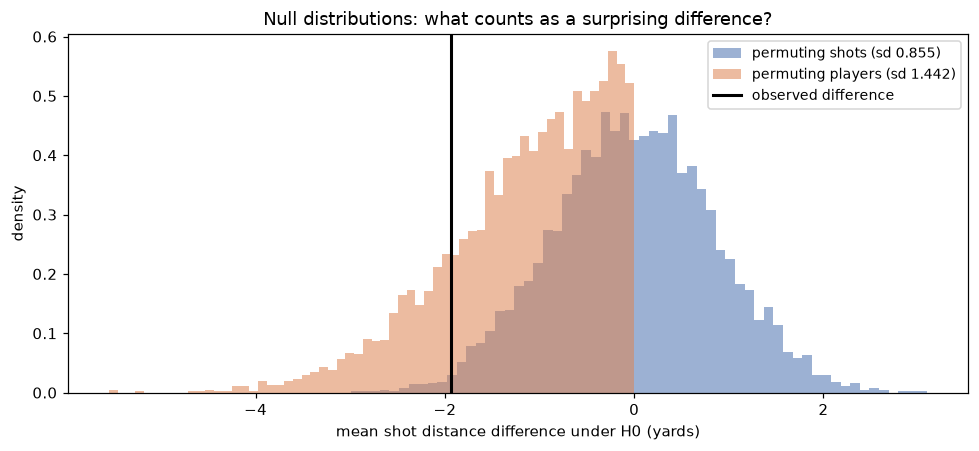

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(
    shot_level.null_distribution,
    bins=60,
    density=True,
    alpha=0.55,
    color="#4C72B0",
    label=f"permuting shots (sd {shot_level.null_std:.3f})",
)
ax.hist(
    np.abs(player_level.null_distribution) * np.sign(shot_level.observed),
    bins=60,
    density=True,
    alpha=0.55,
    color="#DD8452",
    label=f"permuting players (sd {player_level.null_std:.3f})",
)
ax.axvline(shot_level.observed, color="black", linewidth=2, label="observed difference")
ax.set_xlabel("mean shot distance difference under H0 (yards)")
ax.set_ylabel("density")
ax.set_title("Null distributions: what counts as a surprising difference?")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In [29]:
summary = pd.DataFrame(
    {
        "p-value": [
            welch.p_value,
            mwu.p_value,
            ks.p_value,
            shot_level.p_value,
            player_level.p_value,
        ],
        "assumes independent shots": [True, True, True, True, False],
        "question": [
            "difference in means",
            "stochastic ordering",
            "whole distributions",
            "label exchangeable across shots",
            "label exchangeable across players",
        ],
    },
    index=[
        "Welch t-test",
        "Mann-Whitney U",
        "Kolmogorov-Smirnov",
        "permutation (shots)",
        "permutation (players)",
    ],
)
display(summary.round(4))

,p-value,assumes independent shots,question
Welch t-test,0.0233,True,difference in means
Mann-Whitney U,0.0232,True,stochastic ordering
Kolmogorov-Smirnov,0.0645,True,whole distributions
permutation (shots),0.0204,True,label exchangeable across shots
permutation (players),0.1892,False,label exchangeable across players


**Result.** Permuting shots gives p = 0.020; permuting players gives **p = 0.19**,
with a null distribution 1.7x wider (sd 1.44 against 0.85).

**Magnitude.** Unchanged by any of this: the observed difference is 1.93 yards. What
changes is how surprising that difference is under a defensible null.

**Interpretation.** The four procedures that assume independent shots — Welch,
Mann-Whitney, KS and the shot-level permutation — cluster around p = 0.02–0.06. The
one whose assumption actually holds returns 0.19. Under the honest analysis, **a
two-yard difference between these teams is well within what re-labelling 51 players
at random produces.**

Note how closely this agrees with §11: the player bootstrap widened the standard
error by 1.63x, and the player permutation widened the null by 1.69x. Two different
resampling methods, arriving independently at the same conclusion about where the
dependence lives.

**These are not five attempts at one test.** Welch asks about means via the CLT;
Mann-Whitney about stochastic ordering; KS about whole distributions; and the two
permutation tests about exchangeability at different units. Reporting the smallest
of them would be indefensible.

**Limitations.** 51 players is not many. The smallest attainable p-value is bounded
by the number of ways to relabel them, and a real difference of this size would be
hard to detect with this design — so p = 0.19 is *not* evidence that the teams shoot
from the same distance.

**What would make this invalid.** A player appearing for both teams, which would
mean the label varies within a unit — the function refuses to run in that case.

---

## 14. Testing many players at once: multiple comparisons

**Question.** Which players finish at a rate different from the tournament-wide
conversion rate?

**Observational unit.** One shot for each individual test; **one player** for the
family. The family is every player with at least 15 shots — a rule fixed *before*
looking at any conversion rate, which matters: choosing the family after seeing
which players look extreme would invalidate every correction below.

**H0 (per player).** That player's conversion rate equals the rate among all other
shots in the dataset.
**H1 (per player).** It differs.

**Why Fisher's exact test.** Each comparison is a 2x2 table of goals and non-goals
for one player against everyone else. Counts are small for some players, so the
exact test is the natural choice.

### Why running 35 tests changes everything

A threshold of 0.05 means that, when nothing is going on, one test in twenty
rejects anyway. Across a family of *m* independent tests under the global null:

- the **expected number** of false positives is `m x alpha` = 35 x 0.05 = **1.75**;
- the probability of **at least one** is `1 - 0.95^35` = **83.4%**.

So a procedure that tests 35 players and reports whoever comes out under 0.05 will
almost always report somebody, whether or not any player truly differs. The
uncorrected list is not a list of findings; it is a list of the most extreme noise.

### The two guarantees on offer

**Family-wise error rate (FWER)** — the probability of making *at least one* false
rejection anywhere in the family. **Bonferroni** controls it by multiplying every
p-value by *m*. It assumes nothing about how the tests relate to each other, and it
is deliberately harsh.

**False discovery rate (FDR)** — the *expected proportion of false positives among
the rejections actually made*. **Benjamini-Hochberg** controls it by comparing the
k-th smallest p-value to `k x alpha / m`. It is far more powerful when several
effects are real, and assumes the tests are independent or positively dependent.

**When each is preferable.** Bonferroni when a single false positive is expensive
and the family yields one decision — a published claim, a signing, a model shipped
on the strength of it. Benjamini-Hochberg when the output is a *shortlist for
follow-up* and a known fraction of dead ends is an acceptable price for not missing
real effects. "Which players deserve a closer look?" is an FDR question.

In [30]:
per_player = (
    shots.groupby(["player_id", "player"])
    .agg(shots=("goal", "size"), goals=("goal", "sum"))
    .reset_index()
)
MIN_SHOTS = 15  # fixed in advance, not chosen after seeing conversion rates
family = per_player[per_player["shots"] >= MIN_SHOTS].copy()

total_goals = int(shots["goal"].sum())
total_shots = len(shots)
overall_rate = total_goals / total_shots

records = []
for _, player in family.iterrows():
    rest_goals = total_goals - int(player["goals"])
    rest_misses = (total_shots - int(player["shots"])) - rest_goals
    result = ht.fisher_exact_test(
        [[int(player["goals"]), int(player["shots"] - player["goals"])], [rest_goals, rest_misses]]
    )
    records.append(
        {
            "player": player["player"],
            "shots": int(player["shots"]),
            "goals": int(player["goals"]),
            "conversion": player["goals"] / player["shots"],
            "odds_ratio": result.estimate,
            "p_value": result.p_value,
        }
    )

finishing = pd.DataFrame(records)
print(f"family: {len(finishing)} players with at least {MIN_SHOTS} shots")
print(f"tournament-wide conversion rate: {overall_rate:.4f}")
print(f"raw p < 0.05: {(finishing['p_value'] <= 0.05).sum()} players")
print(f"expected false positives under the global null: {len(finishing) * 0.05:.2f}")
print(f"probability of at least one: {1 - 0.95 ** len(finishing):.1%}")

family: 35 players with at least 15 shots
tournament-wide conversion rate: 0.0987
raw p < 0.05: 4 players
expected false positives under the global null: 1.75
probability of at least one: 83.4%


In [31]:
bonf = mt.bonferroni(finishing["p_value"], labels=finishing["player"])
bh = mt.benjamini_hochberg(finishing["p_value"], labels=finishing["player"])
print(bonf)
print()
print(bh)

bonferroni correction (controls the family-wise error rate)
  tests in family   35
  alpha             0.05
  rejected          1 after correction, 4 before
  under the global null, uncorrected testing would reject 1.75 on average (83.4% chance of at least one)
  note              Adjusted p-values are not effect sizes: they grow with the size of the family, while the underlying effect does not.
  note              Bonferroni controls the probability of even one false rejection anywhere in the family, needs no assumption about dependence between tests, and is conservative.

benjamini-hochberg correction (controls the false discovery rate)
  tests in family   35
  alpha             0.05
  rejected          1 after correction, 4 before
  under the global null, uncorrected testing would reject 1.75 on average (83.4% chance of at least one)
  note              Adjusted p-values are not effect sizes: they grow with the size of the family, while the underlying effect does not.
  note        

In [32]:
comparison = mt.compare_corrections(finishing["p_value"], labels=finishing["player"])
table = (
    finishing.set_index("player")[["shots", "goals", "conversion", "odds_ratio"]]
    .join(comparison)
    .sort_values("p_value")
)
display(
    table.head(10)
    .rename(
        columns={
            "p_value": "raw p",
            "bonferroni_p": "Bonferroni p",
            "benjamini_hochberg_p": "BH p",
            "rejected_uncorrected": "raw<.05",
            "rejected_bonferroni": "Bonf",
            "rejected_benjamini_hochberg": "BH",
        }
    )
    .round(4)
)

,shots,goals,conversion,odds_ratio,raw p,Bonferroni p,BH p,raw<.05,Bonf,BH
player,,,,,,,,,,
Harry Kane,30,10,0.3333,4.6942,0.0004,0.0131,0.0131,True,True,True
Romelu Lukaku Menama,27,8,0.2963,3.9263,0.0034,0.1190,0.0595,True,False,False
Cristiano Ronaldo dos Santos Aveiro,37,9,0.2432,2.9977,0.0081,0.2836,0.0945,True,False,False
Patrik Schick,16,5,0.3125,4.2066,0.0158,0.5545,0.1386,True,False,False
Daniel Olmo Carvajal,22,0,0.0000,0.0000,0.1594,1.0000,0.8724,False,False,False
Emil Peter Forsberg,29,5,0.1724,1.9184,0.1997,1.0000,0.8724,False,False,False
Antoine Griezmann,29,5,0.1724,1.9184,0.1997,1.0000,0.8724,False,False,False
Edinson Roberto Cavani Gómez,16,3,0.1875,2.1190,0.2048,1.0000,0.8724,False,False,False
Ivan Perišić,31,5,0.1613,1.7695,0.2243,1.0000,0.8724,False,False,False


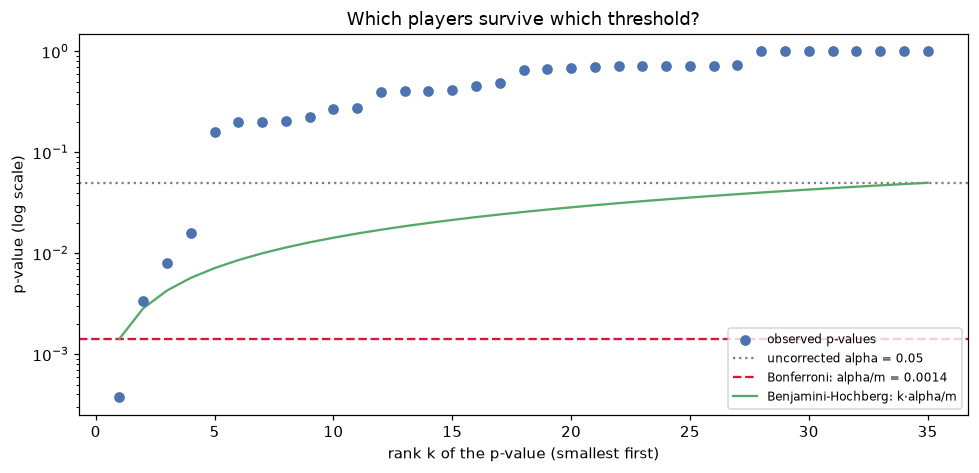

rejected uncorrected : 4
rejected by BH       : 1
rejected by Bonferroni: 1


In [33]:
ordered = np.sort(finishing["p_value"].to_numpy())
ranks = np.arange(1, ordered.size + 1)
alpha = 0.05

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.scatter(ranks, ordered, color="#4C72B0", zorder=3, label="observed p-values")
ax.axhline(alpha, color="grey", linestyle=":", label=f"uncorrected alpha = {alpha}")
ax.axhline(
    alpha / ordered.size,
    color="crimson",
    linestyle="--",
    label=f"Bonferroni: alpha/m = {alpha / ordered.size:.4f}",
)
ax.plot(ranks, ranks * alpha / ordered.size, color="#55A868", label="Benjamini-Hochberg: k·alpha/m")
ax.set_yscale("log")
ax.set_xlabel("rank k of the p-value (smallest first)")
ax.set_ylabel("p-value (log scale)")
ax.set_title("Which players survive which threshold?")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

print(f"rejected uncorrected : {int(comparison['rejected_uncorrected'].sum())}")
print(f"rejected by BH       : {bh.n_rejected}")
print(f"rejected by Bonferroni: {bonf.n_rejected}")

**Result.** Of 35 players, **4 have a raw p-value below 0.05**. After correction,
**1 survives Benjamini-Hochberg and 1 survives Bonferroni** — Harry Kane, 10 goals
from 30 shots, adjusted p = 0.013 under both.

| player | shots | goals | rate | raw p | Bonferroni p | BH p |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Harry Kane | 30 | 10 | 33.3% | 0.0004 | **0.013** | **0.013** |
| Romelu Lukaku | 27 | 8 | 29.6% | 0.0034 | 0.119 | 0.060 |
| Cristiano Ronaldo | 37 | 9 | 24.3% | 0.0081 | 0.284 | 0.095 |
| Patrik Schick | 16 | 5 | 31.3% | 0.0158 | 0.554 | 0.139 |

**How the conclusion changes.** Read uncorrected, this table says "four players
finish significantly better than average". But 1.75 false positives were *expected*
before anyone kicked a ball, and there was an 83% chance of at least one. Three of
the four findings do not survive either correction. The honest summary is: one
player stands out, and even that rests on 30 shots.

**Bonferroni versus BH here.** They agree on the top-ranked test by construction
(both give 35 x 0.0004 = 0.013), and diverge below it: Lukaku's p of 0.0034 becomes
0.119 under Bonferroni but 0.060 under BH. BH is the less harsh of the two and would
have flagged him at alpha = 0.10, which is exactly its intended use — a shortlist,
not a verdict.

**Magnitude — and adjusted p-values are not it.** Kane's odds ratio is **4.69**:
his odds of scoring are about 4.7 times those of the rest of the dataset, or 33.3%
conversion against 9.9%. That number is completely unchanged by any correction. Had
we tested 200 players instead of 35, Kane's adjusted p would have risen to 0.075 and
"the finding" would have disappeared, while his finishing record stayed identical.
An adjusted p-value describes the company a test keeps, not the size of an effect.

**Interpretation.** Some players in this dataset do convert at rates unlikely to
arise from the tournament-wide rate by chance, but far fewer than an uncorrected
scan suggests. Note also what did *not* appear: Dani Olmo scored 0 from 22 shots,
which sounds alarming and has a raw p of 0.16 — at a 9.9% base rate the expected
haul is 2.2 goals, and zero is unremarkable.

**Limitations.**

- **The tests are not independent.** Each player is compared against a pool
  containing all the others, and shots are clustered within players and matches. BH
  assumes independence or positive dependence; under arbitrary dependence the
  Benjamini-Yekutieli variant is the conservative alternative.
- **The comparison group is not like-for-like.** Players with 15+ shots are mostly
  forwards, and they are being compared to a pool that includes defenders shooting
  from distance. Part of any "finishing" effect is chance quality, not finishing.
- **Selection into the family.** Taking many shots is itself informative, so the 35
  players are not a random sample of players.
- **A single tournament run.** With 30 shots, the interval around a 33% conversion
  rate is very wide; regression to the mean should be expected next tournament.

**What would make this invalid.** Choosing the 15-shot threshold after seeing which
cut-off made a favoured player significant, or correcting only the tests that were
reported rather than all the tests that were run. Correction protects the family you
actually looked at.

---

## 15. Effect sizes: how big, and how well do we know?

Every test above answered "could this be chance?". None answered "does it
matter?", and none can. This section returns to the same analyses and attaches the
missing half.

Two kinds of measure are used. **Unstandardised** ones stay in the units of the
problem — yards, percentage points, an odds ratio — and are the ones a coach can
act on. **Standardised** ones (Cohen's d, Cramer's V, the probability of
superiority) divide by a measure of spread so that different quantities can be
compared, at the cost of inheriting whatever the denominator does.

Every estimate below carries an interval. A point estimate without one simply
recreates the problem the effect size was meant to solve.

In [34]:
RESAMPLES = 2000

# 1. The team comparison from sections 2-4.
teams_md = eff.mean_difference(distance_a, distance_b, units="yards")
teams_d = eff.cohens_d(distance_a, distance_b, n_resamples=RESAMPLES, random_state=SEED)
teams_ps = eff.probability_of_superiority(
    distance_a, distance_b, n_resamples=RESAMPLES, random_state=SEED
)
print(teams_md)
print()
print(teams_d)
print()
print(teams_ps)

mean difference
  estimate          -1.93 yards
  95% CI            [-3.597, -0.2641] yards   (Welch t)
  no effect = 0     the interval excludes it
  n                 179 vs 149
  note              Unstandardised: read it in the units of the measurement, which is normally more informative than a standardised alternative.

Cohen's d
  estimate          -0.2534 pooled SD
  95% CI            [-0.4737, -0.03795] pooled SD   (bootstrap percentile, resampled within groups)
  no effect = 0     the interval excludes it
  n                 179 vs 149
  note              Pooled standard deviation (Cohen's d_s); the sign follows the argument order.
  note              Cohen's 0.2/0.5/0.8 labels are conventions, not facts about football. Judge the raw difference against what matters in the game.

probability of superiority
  estimate          0.4272
  95% CI            [0.3646, 0.4873]   (bootstrap percentile, resampled within groups)
  no effect = 0.5     the interval excludes it
  n           

**Reading it.** Spain shoot **1.93 yards closer** on average, 95% CI [−3.60, −0.26]
— the unstandardised measure, and the one worth quoting. Standardised, that is
**d = −0.25** [−0.48, −0.04]: about a quarter of a standard deviation, which by
any convention is a small effect. The probability of superiority is **0.427**
[0.365, 0.488]: pick one shot from each team and Spain's is the longer one 43% of
the time rather than 50%.

All three intervals exclude "no effect", and all three are consistent with an
effect small enough to be of little football consequence. Recall from §13 that once
players rather than shots are treated as the exchangeable unit, even that evidence
dissolves (p = 0.19). **The effect size does not change when the unit changes — only
the uncertainty does.**

### 15a. A small p-value with a negligible effect

The clearest demonstration in this dataset is not a team comparison but a
competition one: shot distance in the World Cup against the Euro. It is also a
warning, because from `01_data_exploration` we know coordinate precision differs
between these two competitions, so part of any difference is measurement.

In [35]:
world_cup = shots.loc[shots["competition_id"] == 43, "shot_distance"]
euro = shots.loc[shots["competition_id"] == 55, "shot_distance"]

competition_test = ht.welch_t_test(world_cup, euro, label_a="World Cup", label_b="Euro")
competition_md = eff.mean_difference(world_cup, euro, units="yards")
competition_d = eff.cohens_d(world_cup, euro, n_resamples=RESAMPLES, random_state=SEED)

print(f"Welch p-value: {competition_test.p_value:.5f}   n = {len(world_cup)} vs {len(euro)}")
print()
print(competition_md)
print()
print(competition_d)

Welch p-value: 0.00148   n = 1667 vs 1251

mean difference
  estimate          0.9904 yards
  95% CI            [0.38, 1.601] yards   (Welch t)
  no effect = 0     the interval excludes it
  n                 1,667 vs 1,251
  note              Unstandardised: read it in the units of the measurement, which is normally more informative than a standardised alternative.

Cohen's d
  estimate          0.1173 pooled SD
  95% CI            [0.04444, 0.1904] pooled SD   (bootstrap percentile, resampled within groups)
  no effect = 0     the interval excludes it
  n                 1,667 vs 1,251
  note              Pooled standard deviation (Cohen's d_s); the sign follows the argument order.
  note              Cohen's 0.2/0.5/0.8 labels are conventions, not facts about football. Judge the raw difference against what matters in the game.


**Result.** p = **0.0015** — by any conventional threshold, decisively
"significant". The effect: **0.99 yards** [0.38, 1.60], or **d = 0.117**
[0.044, 0.190].

**Interpretation.** One yard, on shots taken from an average of 18.8 yards. Both
ends of the interval are trivially small: even the most favourable end, d = 0.19,
is below any threshold anyone would call a meaningful difference. The p-value is
small because n = 2,918, not because the effect is large. Reported as "World Cup
shots are significantly longer than Euro shots (p = 0.0015)" the sentence is true
and thoroughly misleading; reported as "one yard further, 95% CI [0.4, 1.6]" the
reader can see immediately that it does not matter.

And the confound makes it worse: World Cup coordinates are recorded to the nearest
yard and Euro coordinates to a fraction of one, so an unknown part of this yard is
an artefact of measurement rather than a fact about shooting.

### 15b. The same measure on an effect that does matter

For contrast, the body-part comparison from §10, expressed the same way.

In [36]:
headers = subset.loc[subset["body_part"] == "Head", "shot_distance"]
feet = subset.loc[subset["body_part"] != "Head", "shot_distance"]

header_md = eff.mean_difference(headers, feet, units="yards")
header_d = eff.cohens_d(headers, feet, n_resamples=RESAMPLES, random_state=SEED)
print(header_md)
print()
print(header_d)

mean difference
  estimate          -10.85 yards
  95% CI            [-11.27, -10.42] yards   (Welch t)
  no effect = 0     the interval excludes it
  n                 531 vs 2,200
  note              Unstandardised: read it in the units of the measurement, which is normally more informative than a standardised alternative.

Cohen's d
  estimate          -1.519 pooled SD
  95% CI            [-1.59, -1.449] pooled SD   (bootstrap percentile, resampled within groups)
  no effect = 0     the interval excludes it
  n                 531 vs 2,200
  note              Pooled standard deviation (Cohen's d_s); the sign follows the argument order.
  note              Cohen's 0.2/0.5/0.8 labels are conventions, not facts about football. Judge the raw difference against what matters in the game.


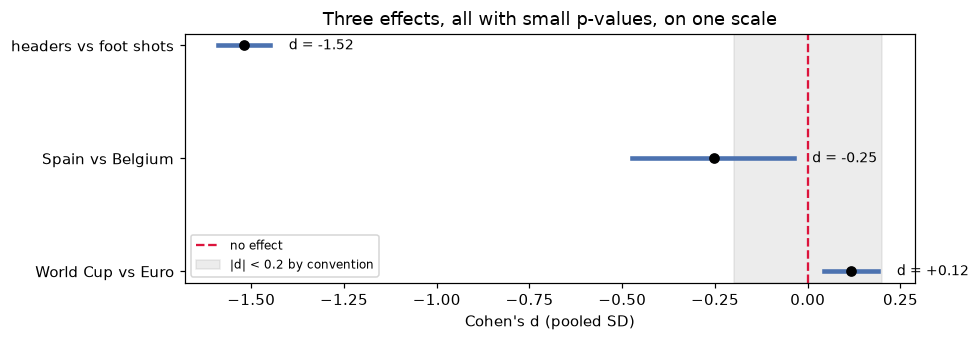

In [37]:
labels = ["World Cup vs Euro", "Spain vs Belgium", "headers vs foot shots"]
effects = [competition_d, teams_d, header_d]

fig, ax = plt.subplots(figsize=(9, 3.2))
for position, effect in enumerate(effects):
    low, high = effect.confidence_interval
    ax.plot([low, high], [position, position], linewidth=3, color="#4C72B0")
    ax.plot(effect.estimate, position, "o", color="black", zorder=3)
    ax.text(high + 0.05, position, f"d = {effect.estimate:+.2f}", va="center", fontsize=9)
ax.axvline(0, color="crimson", linestyle="--", label="no effect")
ax.axvspan(-0.2, 0.2, color="grey", alpha=0.15, label="|d| < 0.2 by convention")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("Cohen's d (pooled SD)")
ax.set_title("Three effects, all with small p-values, on one scale")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

**Result.** Headers are taken **10.85 yards closer** than foot shots, **d = −1.52**
[−1.59, −1.45].

**Statistical versus practical significance, side by side.** Both comparisons
return p-values far below 0.05. One is a fifth of a standard deviation; the other
is one and a half standard deviations, and eleven yards on a pitch. The p-values do
not distinguish them at all — d = 0.117 and d = −1.52 can both be "p < 0.01" — and
only the effect size does. Note too how much narrower the header interval is
relative to its size: that effect is both large and precisely known, which is the
combination that justifies acting on a finding.

### 15c. Categorical effects: association, odds and risk

Back to §5 and §6, where chi-square said p = 0.108 and Fisher said p = 0.078. What
was the magnitude they were failing to establish?

In [38]:
association = eff.cramers_v_from_labels(
    subset["body_part"], subset["goal"], n_resamples=RESAMPLES, random_state=SEED
)
header_table = [
    [int(two_by_two.loc["header", True]), int(two_by_two.loc["header", False])],
    [int(two_by_two.loc["foot", True]), int(two_by_two.loc["foot", False])],
]
header_or = eff.odds_ratio(header_table)
header_rd = eff.risk_difference(header_table)

print(association)
print()
print(header_or)
print()
print(header_rd)

Cramer's V
  estimate          0.04033
  95% CI            [0.01056, 0.08384]   (bootstrap percentile over observations)
  no effect = 0     the interval excludes it
  n                 2,731
  note              Bounded in [0, 1] and, unlike chi-square, does not grow with the sample size.
  note              V cannot go below 0, so its interval is asymmetric and never contains negative values; a lower bound near 0 is the signal that no association is established.

odds ratio (conditional)
  estimate          1.322
  95% CI            [0.9535, 1.813]   (exact conditional)
  no effect = 1     the interval includes it
  n                 2,731
  note              An odds ratio is not a risk ratio and not a difference in probability; report a risk difference alongside it when the outcome is common.

risk difference
  estimate          0.02475 proportion
  95% CI            [-0.002288, 0.05631] proportion   (statsmodels newcomb)
  no effect = 0     the interval includes it
  n              

**Result.** Cramer's V = **0.040** [0.011, 0.084] — an association close to nothing
on a 0-to-1 scale. Headers convert at an odds ratio of **1.32** [0.95, 1.81] and a
risk difference of **+2.5 percentage points** [−0.2, +5.6].

**A subtlety worth pausing on.** V's interval excludes zero, yet the chi-square test
gave p = 0.108. That is not a contradiction and V's interval is *not* evidence of
association: V is bounded below at zero, so a percentile bootstrap interval can
never contain zero even when nothing is going on. A bounded-at-zero statistic needs
a test, not an interval, to address "is there any association?" — which is exactly
what §5 did. The interval is still useful for the other question: however real the
association might be, it is **small**.

**Odds ratio versus risk difference.** The odds ratio of 1.32 sounds more impressive
than the risk difference of 2.5 percentage points, and they describe the same table.
Whenever an outcome is reasonably common, an odds ratio exaggerates the change in
probability, which is why the risk difference belongs beside it. Both intervals
include no effect, so neither establishes one.

### 15d. A meaningful point estimate with useless precision

From §14: Harry Kane converted 10 of 30 shots against a tournament rate of 9.9%,
the only player to survive multiple-testing correction. How well do we know the
size of that effect?

In [39]:
kane = finishing.loc[finishing["player"].str.contains("Harry Kane")].iloc[0]
rest_goals = total_goals - int(kane["goals"])
rest_misses = (total_shots - int(kane["shots"])) - rest_goals
kane_table = [
    [int(kane["goals"]), int(kane["shots"] - kane["goals"])],
    [rest_goals, rest_misses],
]
kane_or = eff.odds_ratio(kane_table)
kane_rd = eff.risk_difference(kane_table)
print(kane_or)
print()
print(kane_rd)

odds ratio (conditional)
  estimate          4.69
  95% CI            [1.94, 10.62]   (exact conditional)
  no effect = 1     the interval excludes it
  n                 2,918
  note              An odds ratio is not a risk ratio and not a difference in probability; report a risk difference alongside it when the outcome is common.

risk difference
  estimate          0.2371 proportion
  95% CI            [0.09559, 0.4162] proportion   (statsmodels newcomb)
  no effect = 0     the interval excludes it
  n                 30 vs 2,888
  note              Row rates are 0.3333 and 0.0963.
  note              In the units of the outcome, so it answers 'how many more per hundred?' directly.


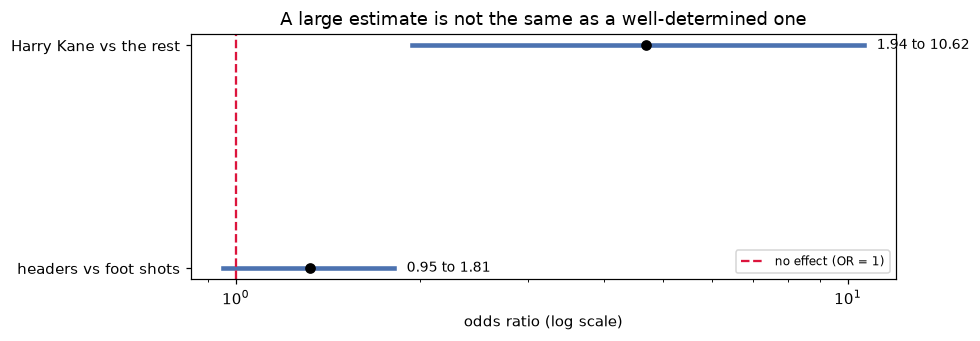

In [40]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ratio_effects = [("headers vs foot shots", header_or), ("Harry Kane vs the rest", kane_or)]
for position, (_name, effect) in enumerate(ratio_effects):
    low, high = effect.confidence_interval
    ax.plot([low, high], [position, position], linewidth=3, color="#4C72B0")
    ax.plot(effect.estimate, position, "o", color="black", zorder=3)
    ax.text(high * 1.05, position, f"{low:.2f} to {high:.2f}", va="center", fontsize=9)
ax.axvline(1.0, color="crimson", linestyle="--", label="no effect (OR = 1)")
ax.set_xscale("log")
ax.set_yticks(range(len(ratio_effects)), [label for label, _ in ratio_effects])
ax.set_xlabel("odds ratio (log scale)")
ax.set_title("A large estimate is not the same as a well-determined one")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Result.** Odds ratio **4.69**, 95% CI **[1.94, 10.62]**. Risk difference **+23.7
percentage points** [+9.6, +41.6].

**Interpretation.** The point estimate is striking and the interval is nearly
useless: it spans a fivefold range, from "roughly twice the odds" to "more than ten
times". Both ends are above 1, so *some* elevation is established — but the data
cannot say whether Kane is a good finisher or an extraordinary one, and 30 shots
never could.

This is the third pattern this section set out to show: a **meaningful point
estimate with large uncertainty**. It is also the honest reading of §14's headline.
Kane survived correction, which means the ordering is unlikely to be noise; it does
not mean 33% is his finishing rate. Regression to the mean should be the default
expectation for whichever player tops such a list next tournament.

**And a reminder about §14.** Multiple-testing correction changed the p-value from
0.0004 to 0.013, and changed nothing here. Adjusted p-values are not effect sizes:
the odds ratio of 4.69 is identical whether we tested one player or two hundred.

---

## 16. What this notebook establishes

**Findings that survive an honest treatment of dependence**

1. **Headers are taken from less than half the distance of foot shots** (9.8 vs
   ~20.5 yards). An eleven-yard gap is far too large for any dependence correction to
   overturn, and it confounds every marginal comparison involving body part.
2. **Overall conversion is 9.87%, 95% CI [8.8%, 11.0%]**, and this interval is
   robust to the choice of resampling unit (1.02x–1.16x inflation).
3. **Mean shot distance is 18.77 yards**, but its uncertainty depends heavily on the
   unit: ±0.16 assuming independent shots, ±0.25 resampling players.

**Findings that do not survive**

4. **The two-yard difference in shot distance between the busiest two teams.** It
   reads as p = 0.023 under independence and p = 0.19 once players are treated as
   the exchangeable unit. The effect estimate does not change; the evidence for it
   evaporates.

**Methodological conclusions**

5. **The resampling unit is a modelling decision, not a formality.** Matches barely
   matter for shot distance (1.07x) while players matter a great deal (1.63x), and
   for conversion rate neither matters much. This is statistic-specific and cannot
   be guessed in advance.
6. **Different tests answer different questions.** Welch (means), Mann-Whitney
   (ordering) and KS (distributions) gave p = 0.023, 0.023 and 0.064 on the same two
   samples. The test must follow from the question.
7. **No result here is reported as "significant" on its own.** Every conclusion pairs
   an estimate with an interval, and several rest on magnitudes that make the
   p-values almost irrelevant.
8. **Scanning many players manufactures findings.** Four of 35 players cleared
   p < 0.05 when 1.75 were expected from noise alone; one survived correction. The
   size of the family is part of the evidence, and adjusted p-values still say
   nothing about magnitude.
9. **Statistical and practical significance came apart repeatedly.** World Cup
   against Euro shot distance is p = 0.0015 with d = 0.12; headers against foot
   shots is d = −1.52. The p-values do not separate them and the effect sizes do.

**What is still missing**

- Formal effect sizes (Cohen's d, Cramér's V, odds-ratio intervals) — the effect-size
  module.
- A mixed model with a player random intercept, which is the principled answer to
  the clustering problem that §10b, §11 and §13 keep running into.

---

## 17. A statistical decision map

A summary of what this project now has and roughly where each piece applies. It is
a map, **not an algorithm**: nothing here should be applied by matching keywords to
a row.

| Situation | Tools | The question that actually decides |
| --- | --- | --- |
| Two independent groups, numeric outcome | `welch_t_test`, `mann_whitney_u_test` | Is the estimand a **difference in means** or an **ordering**? Welch for the first, Mann-Whitney for the second. Not a normality p-value. |
| Paired numeric outcome | `paired_t_test`, `wilcoxon_signed_rank_test` | Is there a real one-to-one matching **by design**? If not, the design is not paired. |
| Three or more independent groups | `one_way_anova`, `welch_anova`, `kruskal_wallis_test` | Do the groups differ in spread? If so, Welch. Is the outcome ordinal or heavy tailed? Then Kruskal-Wallis. |
| Two categorical variables | `chi_square_independence_test`, `fisher_exact_test` | Are expected counts large enough for the approximation? If not, the exact test. |
| Whole distributions, not a summary | `kolmogorov_smirnov_test` | Is the question about shape as well as location? |
| How precise is an estimate? | `bootstrap` (with `clusters=` or `strata=`) | What is the **exchangeable unit**? Rows, matches, players? |
| Could the labels be meaningless? | `permutation_test`, `clustered_permutation_test` | At what level was the label actually assigned? |
| Many hypotheses at once | `bonferroni`, `benjamini_hochberg` | Is a single false positive costly (FWER), or is this a shortlist for follow-up (FDR)? |
| How big is it? | `effect_sizes` | Always. Every test above needs one. |
| Repeated observations from the same unit | **none of the above is sufficient** | Shots within players, players within teams: this needs a mixed or hierarchical model, still to come. |

### How to use it, and how not to

**Start from the design and the estimand, never from the data.** The first two
questions are "what is the observational unit?" and "what quantity do I want to
estimate?". Both are answered before opening the dataset. Only then does the row of
this table become relevant.

**Never let a diagnostic pick the test.** A normality test does not choose between
Welch and Mann-Whitney — they estimate different things, the choice belongs to the
question, and conditioning the choice on the data invalidates the error rate of
whatever runs second (§1, §3).

**Two tools in the same row are not interchangeable.** Welch and Mann-Whitney gave
almost identical p-values in §2 and §3 on this dataset; that was luck. They answer
different questions and can disagree completely.

**Independence is the assumption that failed most often here.** Every row above
except the last assumes it, and shots violate it. §11 and §13 showed the cost:
resampling players rather than shots widened the standard error by 63% and turned
p = 0.02 into p = 0.19. When in doubt, resample the cluster.

**A p-value is never the answer on its own.** Pair it with an estimate and an
interval, and state what would make the analysis invalid. Every section above ends
that way for a reason.